In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/surrey-audiovisual-expressed-emotion-savee/ALL/JE_h09.wav
/kaggle/input/surrey-audiovisual-expressed-emotion-savee/ALL/KL_f12.wav
/kaggle/input/surrey-audiovisual-expressed-emotion-savee/ALL/DC_h03.wav
/kaggle/input/surrey-audiovisual-expressed-emotion-savee/ALL/DC_d04.wav
/kaggle/input/surrey-audiovisual-expressed-emotion-savee/ALL/KL_a14.wav
/kaggle/input/surrey-audiovisual-expressed-emotion-savee/ALL/JE_f01.wav
/kaggle/input/surrey-audiovisual-expressed-emotion-savee/ALL/KL_h15.wav
/kaggle/input/surrey-audiovisual-expressed-emotion-savee/ALL/JK_su02.wav
/kaggle/input/surrey-audiovisual-expressed-emotion-savee/ALL/JK_a06.wav
/kaggle/input/surrey-audiovisual-expressed-emotion-savee/ALL/DC_n01.wav
/kaggle/input/surrey-audiovisual-expressed-emotion-savee/ALL/DC_f01.wav
/kaggle/input/surrey-audiovisual-expressed-emotion-savee/ALL/JK_n22.wav
/kaggle/input/surrey-audiovisual-expressed-emotion-savee/ALL/KL_a10.wav
/kaggle/input/surrey-audiovisual-expressed-emotion-savee/ALL/JE

In [2]:
# ==========================
# IMPORTING REQUIRED LIBRARIES
# ==========================
import pandas as pd
import numpy as np
import os
import sys
import librosa
import librosa.display
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
import IPython.display as ipd
from IPython.display import Audio
import keras
from keras.preprocessing import sequence
from keras.models import Sequential
from keras.layers import Dense, Embedding, LSTM, BatchNormalization, GRU
from keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from keras.layers import Input, Flatten, Dropout, Activation, Conv1D, MaxPooling1D, AveragePooling1D
from keras.models import Model
from keras.callbacks import ModelCheckpoint
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.preprocessing.text import Tokenizer
import warnings
import tensorflow as tf 

# Suppressing warnings
if not sys.warnoptions:
    warnings.simplefilter("ignore")
warnings.filterwarnings("ignore", category=DeprecationWarning) 

print("Done")


Done


In [3]:
# ==========================
# DATASET DIRECTORIES
# ==========================
Crema = "/kaggle/input/cremad/AudioWAV/"
Savee = "/kaggle/input/surrey-audiovisual-expressed-emotion-savee/ALL/"
Emodb = "/kaggle/input/berlin-database-of-emotional-speech-emodb/wav"

In [6]:
# ==========================
# LOADING AND LABELING CREMA-D DATASET
# ==========================
crema_directory_list = os.listdir(Crema)
file_emotion = []
file_path = []

for file in crema_directory_list:
    file_path.append(Crema + file)
    part = file.split('_')
    if part[2] == 'SAD':
        file_emotion.append('sad')
    elif part[2] == 'ANG':
        file_emotion.append('angry')
    elif part[2] == 'DIS':
        file_emotion.append('disgust')
    elif part[2] == 'FEA':
        file_emotion.append('fear')
    elif part[2] == 'HAP':
        file_emotion.append('happy')
    elif part[2] == 'NEU':
        file_emotion.append('neutral')
    else:
        file_emotion.append('Unknown')

# Creating DataFrame
emotion_df = pd.DataFrame(file_emotion, columns=['Emotions'])
path_df = pd.DataFrame(file_path, columns=['Path'])
Crema_df = pd.concat([emotion_df, path_df], axis=1)
print(Crema_df.Emotions.value_counts())




Emotions
disgust    1271
happy      1271
sad        1271
fear       1271
angry      1271
neutral    1087
Name: count, dtype: int64


In [7]:
# ==========================
# LOADING AND LABELING SAVEE DATASET
# ==========================
savee_directory_list = os.listdir(Savee)
file_emotion = []
file_path = []

for file in savee_directory_list:
    file_path.append(Savee + file)
    part = file.split('_')[1]
    ele = part[:-6]
    if ele == 'a':
        file_emotion.append('angry')
    elif ele == 'd':
        file_emotion.append('disgust')
    elif ele == 'f':
        file_emotion.append('fear')
    elif ele == 'h':
        file_emotion.append('happy')
    elif ele == 'n':
        file_emotion.append('neutral')
    elif ele == 'sa':
        file_emotion.append('sad')
    else:
        file_emotion.append('surprise')

# Creating DataFrame
emotion_df = pd.DataFrame(file_emotion, columns=['Emotions'])
path_df = pd.DataFrame(file_path, columns=['Path'])
Savee_df = pd.concat([emotion_df, path_df], axis=1)
print(Savee_df.Emotions.value_counts())


Emotions
neutral     120
fear         60
happy        60
disgust      60
angry        60
surprise     60
sad          60
Name: count, dtype: int64


In [8]:
# ==========================
# LOADING AND LABELING EMO-DB DATASET
# ==========================
emodb_emotions = {
    'W': 'angry', 'L': 'boredom', 'E': 'disgust', 'A': 'fear',
    'F': 'happy', 'T': 'sad', 'N': 'neutral'
}

file_emotion = []
file_path = []
emodb_files = os.listdir(Emodb)

for file in emodb_files:
    if file.endswith(".wav"):
        file_path.append(os.path.join(Emodb, file))
        emotion_label = file[5]
        file_emotion.append(emodb_emotions.get(emotion_label, "unknown"))

# Creating DataFrame
emotion_df = pd.DataFrame(file_emotion, columns=['Emotions'])
path_df = pd.DataFrame(file_path, columns=['Path'])
emodb_df = pd.concat([emotion_df, path_df], axis=1)

print(emodb_df.head())
print("\nEmotion Distribution:")
print(emodb_df.Emotions.value_counts())

  Emotions                                               Path
0    happy  /kaggle/input/berlin-database-of-emotional-spe...
1    happy  /kaggle/input/berlin-database-of-emotional-spe...
2    angry  /kaggle/input/berlin-database-of-emotional-spe...
3    angry  /kaggle/input/berlin-database-of-emotional-spe...
4    angry  /kaggle/input/berlin-database-of-emotional-spe...

Emotion Distribution:
Emotions
angry      127
boredom     81
neutral     79
happy       71
fear        69
sad         62
disgust     46
Name: count, dtype: int64


In [9]:
# ==========================
# COMBINING DATASETS
# ==========================
data_path = pd.concat([emodb_df, Crema_df, Savee_df], axis=0)
data_path.to_csv("data_path.csv", index=False)
print(data_path.Emotions.value_counts())




Emotions
angry       1458
happy       1402
fear        1400
sad         1393
disgust     1377
neutral     1286
boredom       81
surprise      60
Name: count, dtype: int64


In [10]:
# ==========================
# FEATURE EXTRACTION FUNCTIONS
# ==========================
# Zero Crossing Rate (ZCR)
def zcr(data, frame_length=2048, hop_length=512):
    return np.squeeze(librosa.feature.zero_crossing_rate(y=data, frame_length=frame_length, hop_length=hop_length))

# Root Mean Square Energy (RMSE)
def rmse(data, frame_length=2048, hop_length=512):
    return np.squeeze(librosa.feature.rms(y=data, frame_length=frame_length, hop_length=hop_length))

# Mel-Frequency Cepstral Coefficients (MFCC)
def mfcc(data, sr, frame_length=2048, hop_length=512, flatten=True):
    mfcc_features = librosa.feature.mfcc(y=data, sr=sr, n_mfcc=13)
    return np.ravel(mfcc_features.T) if flatten else np.squeeze(mfcc_features.T)

# Feature Extraction
def extract_features(data, sr=22050, frame_length=2048, hop_length=512):
    return np.hstack((zcr(data, frame_length, hop_length),
                      rmse(data, frame_length, hop_length),
                      mfcc(data, sr, frame_length, hop_length)))


In [11]:
# ==========================
# DATA AUGMENTATION FUNCTIONS
# ==========================
# Noise Augmentation
def noise(data):
    noise_amp = 0.035 * np.random.uniform() * np.amax(data)
    return data + noise_amp * np.random.normal(size=data.shape[0])

# Pitch Shift
def pitch(data, sampling_rate, pitch_factor=0.7):
    return librosa.effects.pitch_shift(y=data, sr=sampling_rate, n_steps=pitch_factor)

In [12]:
# ==========================
# FUNCTION TO PROCESS AUDIO FILES
# ==========================
def get_features(path, duration=2.5, offset=0.6):
    data, sr = librosa.load(path, duration=duration, offset=offset)
    audio = np.array(extract_features(data, sr))
    
    noised_audio = noise(data)
    audio = np.vstack((audio, extract_features(noised_audio, sr)))
    
    pitched_audio = pitch(data, sr)
    audio = np.vstack((audio, extract_features(pitched_audio, sr)))
    
    pitched_audio1 = pitch(data, sr)
    pitched_noised_audio = noise(pitched_audio1)
    audio = np.vstack((audio, extract_features(pitched_noised_audio, sr)))

    return audio


In [13]:
# ==========================
# EXTRACTING FEATURES FROM ALL AUDIO FILES
# ==========================
import time
from tqdm import tqdm

start = time.time()
X, Y = [], []

for index, (path, emotion) in tqdm(enumerate(zip(data_path.Path, data_path.Emotions)), total=len(data_path)):
    features = get_features(path)
    X.extend(features)
    Y.extend([emotion] * len(features))

    if index % 500 == 0 and index > 0:
        print(f'{index} audio files have been processed')

print("Processing Completed!")
print(f"Total Time Taken: {time.time() - start:.2f} seconds")

  6%|▌         | 502/8457 [01:19<17:18,  7.66it/s] 

500 audio files have been processed


 12%|█▏        | 1003/8457 [02:21<13:14,  9.39it/s]

1000 audio files have been processed


 18%|█▊        | 1502/8457 [03:25<15:40,  7.39it/s]

...

7500 audio files have been processed


 95%|█████████▍| 8002/8457 [17:12<01:01,  7.45it/s]

8000 audio files have been processed


100%|██████████| 8457/8457 [18:11<00:00,  7.74it/s]

Processing Completed!
Total Time Taken: 1091.98 seconds


In [14]:
print("Length of X:", len(X))
print("Length of Y:", len(Y))
print("Shape of data_path.Path:", data_path.Path.shape)
print("Number of extracted audio files:", len(data_path.Path))


Length of X: 33828
Length of Y: 33828
Shape of data_path.Path: (8457,)
Number of extracted audio files: 8457


In [15]:
Emotions = pd.DataFrame(X)  # Converting feature matrix X into a DataFrame
Emotions['Emotions'] = Y  # Adding the target column (emotions) to the DataFrame
Emotions.to_csv('emotion.csv', index=False)  # Saving the DataFrame to a CSV file
Emotions.head()  # Displaying the first few rows of the DataFrame


,0,1,2,3,4,5,6,7,8,9,...,1611,1612,1613,1614,1615,1616,1617,1618,1619,Emotions
0,0.095215,0.107422,0.121582,0.110352,0.056641,0.050781,0.072754,0.068848,0.071289,0.109375,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,happy
1,0.185059,0.222656,0.246582,0.160156,0.119629,0.149414,0.203613,0.205566,0.195801,0.191406,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,happy
2,0.092285,0.127441,0.153320,0.138184,0.103027,0.083008,0.116211,0.136230,0.133789,0.142090,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,happy
3,0.153320,0.193359,0.219238,0.148926,0.108398,0.087891,0.120117,0.146973,0.141602,0.148926,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,happy
4,0.039062,0.054688,0.067383,0.056641,0.047363,0.039551,0.034180,0.032227,0.035645,0.045410,...,9.435833,18.692459,-4.647604,9.822657,-4.368944,-15.883053,2.286403,-10.53232,-9.982716,happy


In [16]:
# ==========================
# Checking and Handling Missing Values
# ==========================


print(Emotions.isna().any())  # Checking if any column has missing values

Emotions = Emotions.fillna(0)  # Filling NaN values with 0
print(Emotions.isna().any())  # Verifying that there are no more missing values

Emotions.shape  # Printing the shape of the DataFrame

0           False
1           False
2           False
3           False
4           False
            ...  
1616         True
1617         True
1618         True
1619         True
Emotions    False
Length: 1621, dtype: bool
0           False
1           False
2           False
3           False
4           False
            ...  
1616        False
1617        False
1618        False
1619        False
Emotions    False
Length: 1621, dtype: bool


(33828, 1621)

In [23]:
# ==========================
#  Splitting Features and Labels
# ==========================

X = Emotions.iloc[:, :-1].values  # Extracting feature values (all columns except the last one)
Y = Emotions['Emotions'].values  # Extracting target labels (last column)


In [24]:
# ==========================
#  One-Hot Encoding the Labels
# ==========================


from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder()
Y = encoder.fit_transform(np.array(Y).reshape(-1,1)).toarray()

print(Y.shape)
print(X.shape)


(33828, 8)
(33828, 1620)


In [25]:
# ==========================
#   Splitting the Data into Training and Testing Sets
# ==========================


from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(X, Y, random_state=42, test_size=0.2, shuffle=True)
x_train.shape, y_train.shape, x_test.shape, y_test.shape


((27062, 1620), (27062, 8), (6766, 1620), (6766, 8))

In [26]:
# Standardizing before reshaping
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)  # Fit & transform training data
x_test = scaler.transform(x_test)  # Transform test data



In [27]:
# Reshape for deep learning models
X_train = x_train.reshape(x_train.shape[0], x_train.shape[1], 1)
X_test = x_test.reshape(x_test.shape[0], x_test.shape[1], 1)


CNN+LSTM

In [28]:
import keras
from keras.preprocessing import sequence
from keras.models import Sequential
from keras.layers import Dense, Embedding
from keras.layers import LSTM,BatchNormalization , GRU
# from keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.text import Tokenizer
from keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from keras.layers import Input, Flatten, Dropout, Activation
from keras.layers import Conv1D, MaxPooling1D, AveragePooling1D
from keras.models import Model
from keras.callbacks import ModelCheckpoint
from tensorflow.keras.optimizers import SGD

In [29]:
from keras.callbacks import ModelCheckpoint, EarlyStopping,ReduceLROnPlateau

In [30]:
early_stop=EarlyStopping(monitor='val_acc',mode='auto',patience=5,restore_best_weights=True)
lr_reduction=ReduceLROnPlateau(monitor='val_acc',patience=3,verbose=1,factor=0.5,min_lr=0.00001)

In [31]:
model_cnn_lstm = Sequential()
model_cnn_lstm.add(Conv1D(256, kernel_size=5, strides=1, padding='same', activation='relu', input_shape=(X.shape[1], 1)))
model_cnn_lstm.add(MaxPooling1D(pool_size=2, strides=2, padding='same'))
model_cnn_lstm.add(BatchNormalization())
model_cnn_lstm.add(Dropout(0.3))

model_cnn_lstm.add(Conv1D(512, kernel_size=5, strides=1, padding='same', activation='relu'))
model_cnn_lstm.add(MaxPooling1D(pool_size=2, strides=2, padding='same'))
model_cnn_lstm.add(BatchNormalization())
model_cnn_lstm.add(Dropout(0.3))

model_cnn_lstm.add(Conv1D(256, kernel_size=5, strides=1, padding='same', activation='relu'))
model_cnn_lstm.add(MaxPooling1D(pool_size=2, strides=2, padding='same'))
model_cnn_lstm.add(BatchNormalization())
model_cnn_lstm.add(Dropout(0.3))

model_cnn_lstm.add(LSTM(128, return_sequences=True))
model_cnn_lstm.add(Dropout(0.3))

model_cnn_lstm.add(LSTM(128, return_sequences=True))
model_cnn_lstm.add(Dropout(0.3))

model_cnn_lstm.add(LSTM(128))
model_cnn_lstm.add(Dropout(0.3))

model_cnn_lstm.add(Dense(128, activation='relu'))
# model_cnn_lstm.add(Dropout(0.3))

model_cnn_lstm.add(Dense(64, activation='relu'))
# model_cnn_lstm.add(Dropout(0.3))

model_cnn_lstm.add(Dense(32, activation='relu'))
# model_cnn_lstm.add(Dropout(0.3))

model_cnn_lstm.add(Dense(8, activation='softmax'))

model_cnn_lstm.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                      │ (None, 1620, 256)           │           1,536 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d (MaxPooling1D)         │ (None, 810, 256)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 810, 256)            │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 810, 256)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_1 (Conv1D)                    │ (None, 810, 512)            │         655,872 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_1 (MaxPooling1D)       │ (None, 405, 512)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 405, 512)            │           2,048 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 405, 512)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_2 (Conv1D)                    │ (None, 405, 256)            │         655,616 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_2 (MaxPooling1D)       │ (None, 203, 256)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 203, 256)            │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 203, 256)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm (LSTM)                          │ (None, 203, 128)            │         197,120 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 203, 128)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 203, 128)            │         131,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 203, 128)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_2 (LSTM)                        │ (None, 128)                 │         131,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,2

 Total params: 1,804,520 (6.88 MB)

 Trainable params: 1,802,472 (6.88 MB)

 Non-trainable params: 2,048 (8.00 KB)

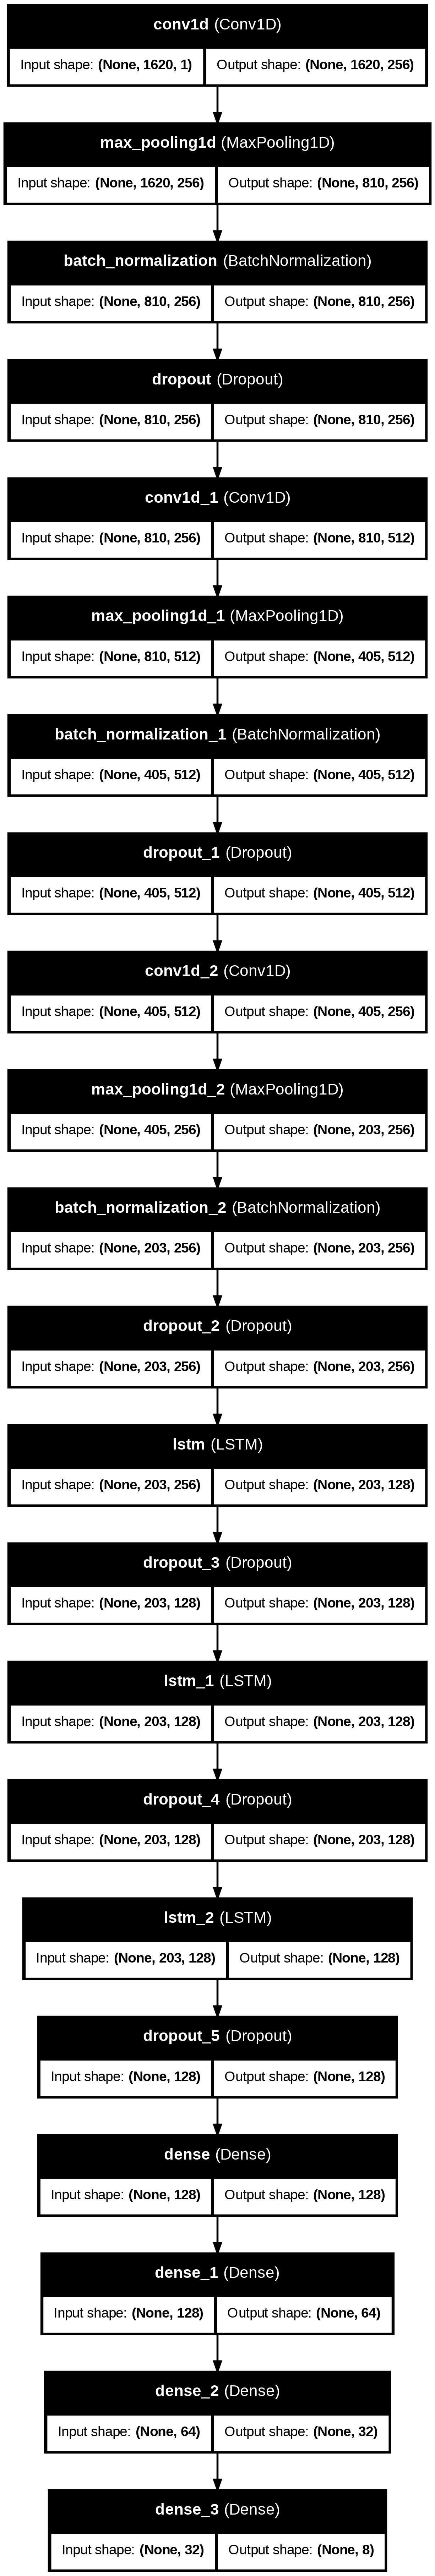

In [32]:
import matplotlib.pyplot as plt
from tensorflow.keras.utils import plot_model

# Create the plot and save it
plot_model(model_cnn_lstm, show_shapes=True, show_layer_names=True, to_file='model_cnn_lstm.png')




In [33]:
model_cnn_lstm.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

In [34]:
history_cnn_lstm = model_cnn_lstm.fit(X_train, y_train, 
                        epochs=75, 
                        batch_size=32, 
                        validation_data=(X_test, y_test))

Epoch 1/75
846/846 ━━━━━━━━━━━━━━━━━━━━ 90s 96ms/step - accuracy: 0.2113 - loss: 1.8477 - val_accuracy: 0.2956 - val_loss: 1.6683
Epoch 2/75
846/846 ━━━━━━━━━━━━━━━━━━━━ 85s 101ms/step - accuracy: 0.3285 - loss: 1.6620 - val_accuracy: 0.3741 - val_loss: 1.5699
Epoch 3/75
846/846 ━━━━━━━━━━━━━━━━━━━━ 85s 100ms/step - accuracy: 0.3544 - loss: 1.6132 - val_accuracy: 0.3779 - val_loss: 1.5670
Epoch 4/75
846/846 ━━━━━━━━━━━━━━━━━━━━ 85s 101ms/step - accuracy: 0.3726 - loss: 1.5734 - val_accuracy: 0.3763 - val_loss: 1.5438
Epoch 5/75
846/846 ━━━━━━━━━━━━━━━━━━━━ 85s 101ms/step - accuracy: 0.3758 - loss: 1.5567 - val_accuracy: 0.3914 - val_loss: 1.5232
Epoch 6/75
846/846 ━━━━━━━━━━━━━━━━━━━━ 85s 100ms/step - accuracy: 0.3817 - loss: 1.5533 - val_accuracy: 0.3903 - val_loss: 1.5198
Epoch 7/75
846/846 ━━━━━━━━━━━━━━━━━━━━ 85s 101ms/step - accuracy: 0.3907 - loss: 1.5398 - val_accuracy: 0.3843 - val_loss: 1.5463
Epoch 8/75
846/846 ━━━━━━━━━━━━━━━━━━━━ 85s 101ms/step - accuracy: 0.3934 - loss: 1.

In [35]:
import matplotlib.pyplot as plt

# Extract metrics
train_loss = history_cnn_lstm.history['loss']
val_loss = history_cnn_lstm.history['val_loss']
train_acc = history_cnn_lstm.history['accuracy']
val_acc = history_cnn_lstm.history['val_accuracy']

# Print final values
print(f"Final Training Accuracy: {train_acc[-1]:.4f}")
print(f"Final Validation Accuracy: {val_acc[-1]:.4f}")
print(f"Final Training Loss: {train_loss[-1]:.4f}")
print(f"Final Validation Loss: {val_loss[-1]:.4f}")



Final Training Accuracy: 0.7485
Final Validation Accuracy: 0.6676
Final Training Loss: 0.6825
Final Validation Loss: 0.9144


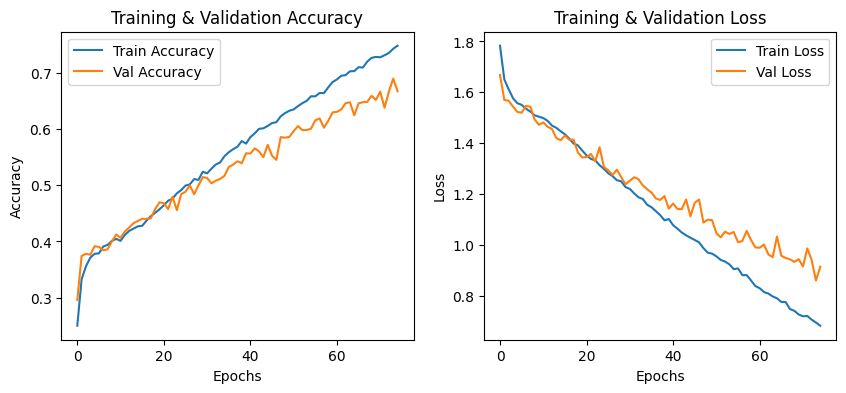

In [36]:
# Plot Training & Validation Accuracy
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(train_acc, label='Train Accuracy')
plt.plot(val_acc, label='Val Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training & Validation Accuracy')

# Plot Training & Validation Loss
plt.subplot(1, 2, 2)
plt.plot(train_loss, label='Train Loss')
plt.plot(val_loss, label='Val Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training & Validation Loss')

plt.show()


212/212 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step


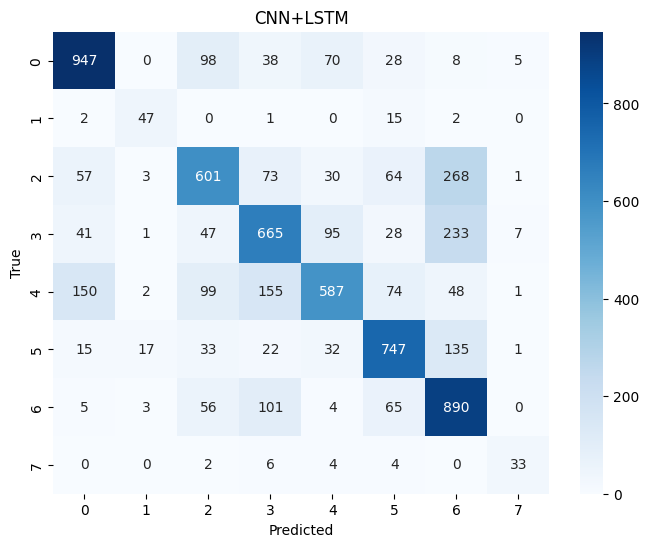

Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.79      0.79      1194
           1       0.64      0.70      0.67        67
           2       0.64      0.55      0.59      1097
           3       0.63      0.60      0.61      1117
           4       0.71      0.53      0.61      1116
           5       0.73      0.75      0.74      1002
           6       0.56      0.79      0.66      1124
           7       0.69      0.67      0.68        49

    accuracy                           0.67      6766
   macro avg       0.67      0.67      0.67      6766
weighted avg       0.68      0.67      0.67      6766



In [37]:
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Get predictions
y_pred = model_cnn_lstm.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)  # Convert to class labels
y_true = np.argmax(y_test, axis=1)  # Convert one-hot encoded labels back to class labels

# Generate Confusion Matrix
conf_matrix = confusion_matrix(y_true, y_pred_classes)

# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap="Blues", xticklabels=range(8), yticklabels=range(8))
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('CNN+LSTM')
plt.show()

# Print Classification Report
print("Classification Report:\n", classification_report(y_true, y_pred_classes))


212/212 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step


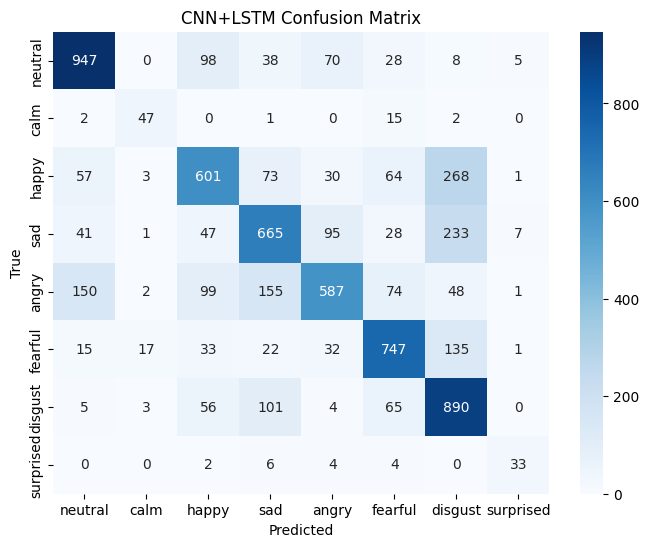

Classification Report:
               precision    recall  f1-score   support

     neutral       0.78      0.79      0.79      1194
        calm       0.64      0.70      0.67        67
       happy       0.64      0.55      0.59      1097
         sad       0.63      0.60      0.61      1117
       angry       0.71      0.53      0.61      1116
     fearful       0.73      0.75      0.74      1002
     disgust       0.56      0.79      0.66      1124
   surprised       0.69      0.67      0.68        49

    accuracy                           0.67      6766
   macro avg       0.67      0.67      0.67      6766
weighted avg       0.68      0.67      0.67      6766



In [38]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

# Define emotion labels
emotion_labels = ["neutral", "calm", "happy", "sad", "angry", "fearful", "disgust", "surprised"]

# Get predictions
y_pred = model_cnn_lstm.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)  # Convert to class labels
y_true = np.argmax(y_test, axis=1)  # Convert one-hot encoded labels back to class labels

# Generate Confusion Matrix
conf_matrix = confusion_matrix(y_true, y_pred_classes)

# Plot Confusion Matrix with Emotion Labels
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap="Blues", xticklabels=emotion_labels, yticklabels=emotion_labels)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('CNN+LSTM Confusion Matrix')
plt.show()

# Print Classification Report with Emotion Labels
print("Classification Report:\n", classification_report(y_true, y_pred_classes, target_names=emotion_labels))


In [39]:
import numpy as np
import pandas as pd

# Define emotion labels
emotion_labels = ["neutral", "calm", "happy", "sad", "angry", "fearful", "disgust", "surprised"]

# Get predictions
y_pred = model_cnn_lstm.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)  # Convert to class labels
y_true = np.argmax(y_test, axis=1)  # Convert one-hot encoded labels back to class labels

# Create a DataFrame to display results
results_df = pd.DataFrame({
    "Actual Label": [emotion_labels[i] for i in y_true],
    "Predicted Label": [emotion_labels[i] for i in y_pred_classes]
})

# Display the first 10 results
print(results_df.head(10))


212/212 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step
  Actual Label Predicted Label
0      disgust         disgust
1      fearful         fearful
2          sad             sad
3      neutral           angry
4        happy           happy
5      fearful         fearful
6        angry         neutral
7      disgust         neutral
8        happy           happy
9      disgust         disgust


CNN+GRU

In [47]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, GRU, Dense, Dropout, BatchNormalization

# Define CNN + GRU model
def create_cnn_gru_model(input_shape, num_classes):
    model = Sequential([
    Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=input_shape),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),
    
    Conv1D(filters=128, kernel_size=3, activation='relu'),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),
    
    GRU(128, return_sequences=True),
    GRU(64),
    
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')
    ])
    
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# Example usage
input_shape = (1620, 1) # Adjust according to your feature size
num_classes = 8 # Number of emotion categories

model_cnn_gru = create_cnn_gru_model(input_shape, num_classes)
model_cnn_gru.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d_5 (Conv1D)                    │ (None, 1618, 64)            │             256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_5                │ (None, 1618, 64)            │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_5 (MaxPooling1D)       │ (None, 809, 64)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_9 (Dropout)                  │ (None, 809, 64)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_6 (Conv1D)                    │ (None, 807, 128)            │          24,704 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_6                │ (None, 807, 128)            │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_6 (MaxPooling1D)       │ (None, 403, 128)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_10 (Dropout)                 │ (None, 403, 128)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ gru_2 (GRU)                          │ (None, 403, 128)            │          99,072 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ gru_3 (GRU)                          │ (None, 64)                  │          37,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_11 (Dropout)                 │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 8)                   │             520 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 166,728 (651.28 KB)

 Trainable params: 166,344 (649.78 KB)

 Non-trainable params: 384 (1.50 KB)

In [48]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(monitor='val_accuracy', mode='max', patience=5, restore_best_weights=True)
lr_reduction = ReduceLROnPlateau(monitor='val_accuracy', patience=3, factor=0.5, min_lr=0.00001, verbose=1)
checkpoint = ModelCheckpoint('best_model.keras', monitor='val_accuracy', save_best_only=True, mode='max')


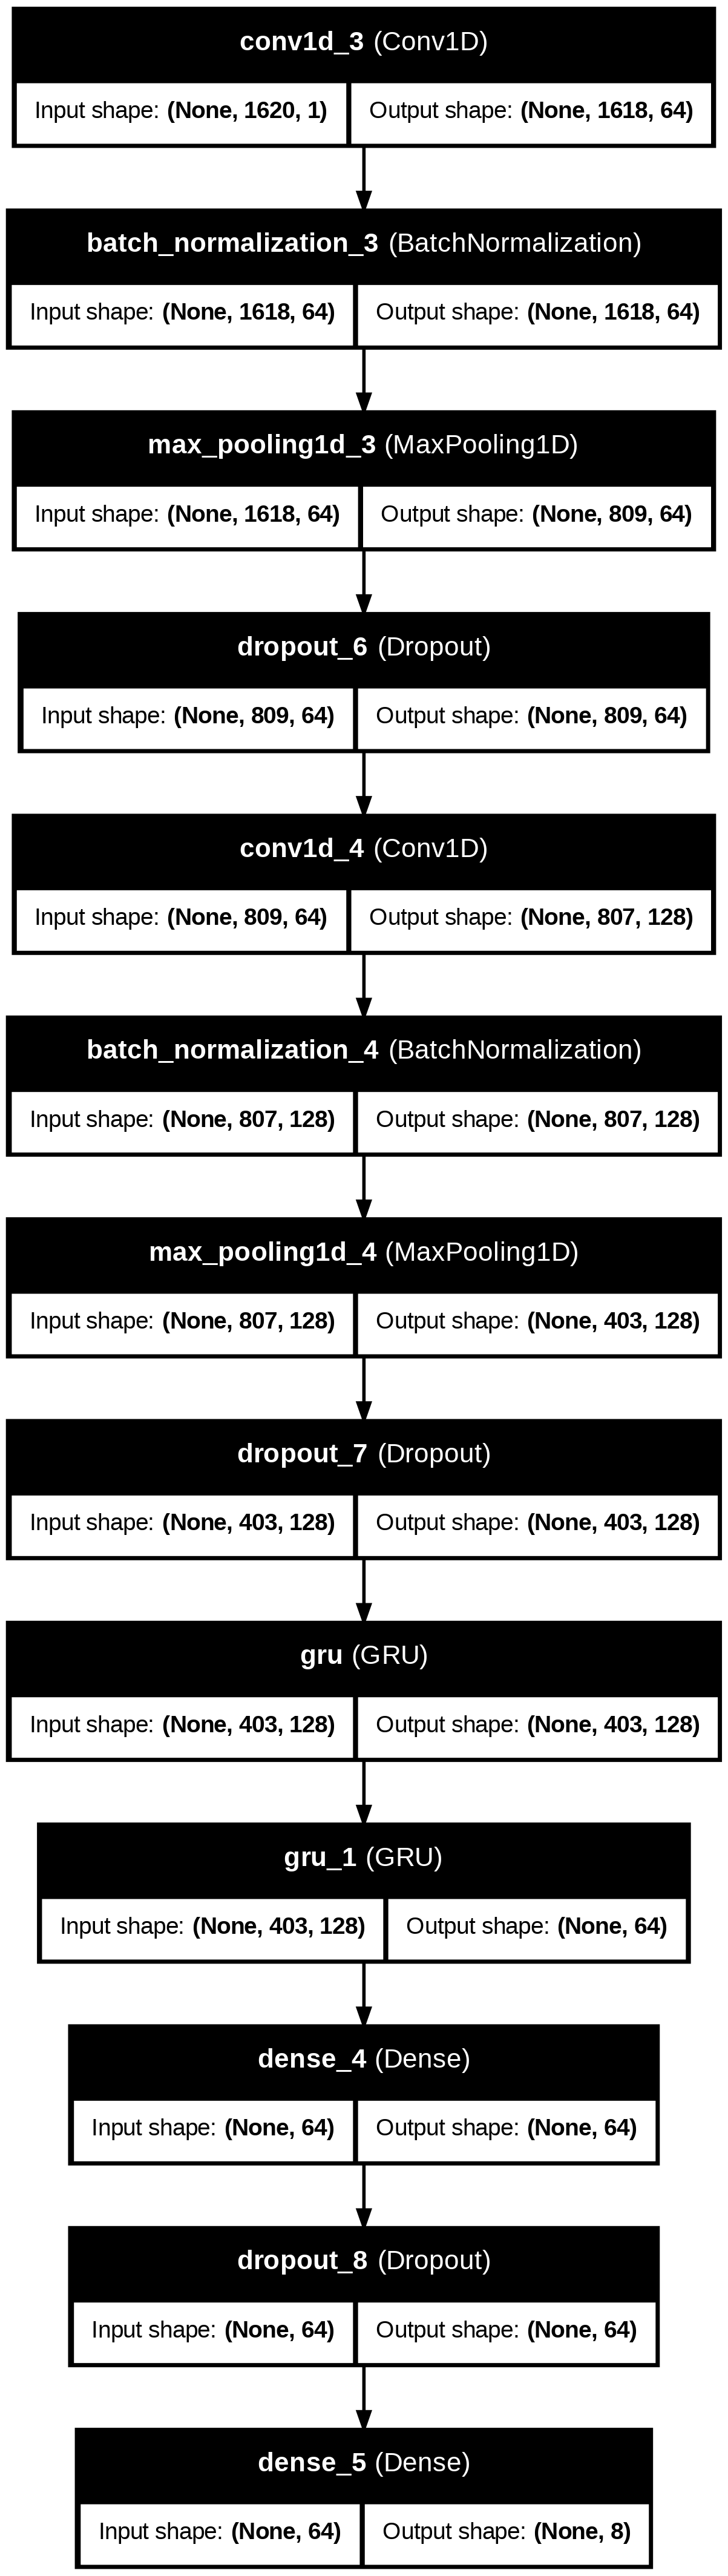

In [42]:
import matplotlib.pyplot as plt
from tensorflow.keras.utils import plot_model

# Create the plot and save it
plot_model(model_cnn_gru, show_shapes=True, show_layer_names=True, to_file='model_cnn_gru.png')



In [ ]:
history_cnn_gru = model_cnn_gru.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=50,  # Adjust based on performance
    batch_size=32,  # Try 32, 64, or 128 based on GPU memory
    callbacks=[early_stop, lr_reduction, checkpoint]
)


Epoch 1/50
846/846 ━━━━━━━━━━━━━━━━━━━━ 35s 38ms/step - accuracy: 0.1880 - loss: 1.8925 - val_accuracy: 0.2363 - val_loss: 1.7864 - learning_rate: 0.0010
Epoch 2/50
846/846 ━━━━━━━━━━━━━━━━━━━━ 32s 38ms/step - accuracy: 0.2988 - loss: 1.7039 - val_accuracy: 0.3958 - val_loss: 1.5294 - learning_rate: 0.0010
Epoch 3/50
846/846 ━━━━━━━━━━━━━━━━━━━━ 32s 37ms/step - accuracy: 0.3866 - loss: 1.5409 - val_accuracy: 0.4206 - val_loss: 1.4696 - learning_rate: 0.0010
Epoch 4/50
846/846 ━━━━━━━━━━━━━━━━━━━━ 32s 37ms/step - accuracy: 0.4100 - loss: 1.5003 - val_accuracy: 0.4313 - val_loss: 1.4406 - learning_rate: 0.0010
Epoch 5/50
846/846 ━━━━━━━━━━━━━━━━━━━━ 32s 37ms/step - accuracy: 0.4297 - loss: 1.4504 - val_accuracy: 0.4659 - val_loss: 1.3657 - learning_rate: 0.0010
Epoch 6/50
846/846 ━━━━━━━━━━━━━━━━━━━━ 32s 37ms/step - accuracy: 0.4577 - loss: 1.4028 - val_accuracy: 0.4814 - val_loss: 1.3354 - learning_rate: 0.0010
Epoch 7/50
846/846 ━━━━━━━━━━━━━━━━━━━━ 32s 37ms/step - accuracy: 0.4717 - l

Final Training Accuracy: 80.80%
Final Validation Accuracy: 72.11%
Final Training Loss: 0.5148
Final Validation Loss: 0.7971
212/212 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step
Test Accuracy: 72.29%
Precision: 72.55%
Recall: 72.29%
F1 Score: 72.29%


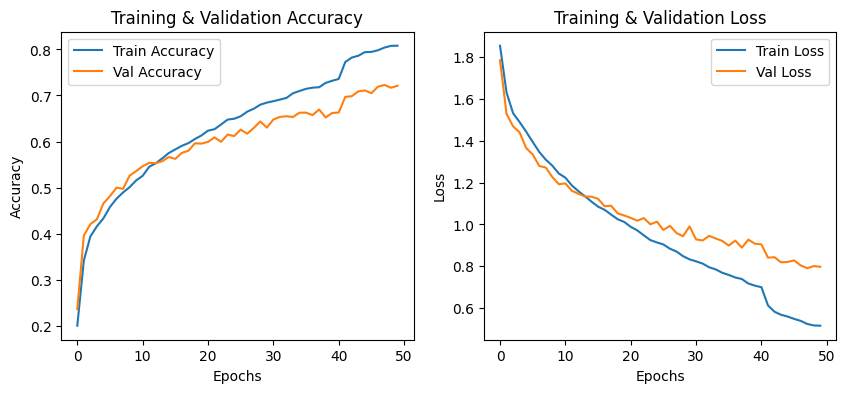

In [50]:

import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Extract metrics from history
train_loss = history_cnn_gru.history['loss']
val_loss = history_cnn_gru.history['val_loss']
train_acc = history_cnn_gru.history['accuracy']
val_acc = history_cnn_gru.history['val_accuracy']

# Print final values in percentages
print(f"Final Training Accuracy: {train_acc[-1] * 100:.2f}%")
print(f"Final Validation Accuracy: {val_acc[-1] * 100:.2f}%")
print(f"Final Training Loss: {train_loss[-1]:.4f}")
print(f"Final Validation Loss: {val_loss[-1]:.4f}")

# Get predictions
pred_test0 = model_cnn_gru.predict(X_test)

# Convert softmax probabilities to class labels
y_pred0 = np.argmax(pred_test0, axis=1)
y_test0 = np.argmax(y_test, axis=1)

# Calculate evaluation metrics
accuracy = accuracy_score(y_test0, y_pred0) * 100
precision = precision_score(y_test0, y_pred0, average='weighted') * 100
recall = recall_score(y_test0, y_pred0, average='weighted') * 100
f1 = f1_score(y_test0, y_pred0, average='weighted') * 100

# Print values in percentage format
print(f"Test Accuracy: {accuracy:.2f}%")
print(f"Precision: {precision:.2f}%")
print(f"Recall: {recall:.2f}%")
print(f"F1 Score: {f1:.2f}%")

# Plot Training & Validation Accuracy
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(train_acc, label='Train Accuracy')
plt.plot(val_acc, label='Val Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training & Validation Accuracy')

# Plot Training & Validation Loss
plt.subplot(1, 2, 2)
plt.plot(train_loss, label='Train Loss')
plt.plot(val_loss, label='Val Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training & Validation Loss')

plt.show()

212/212 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step


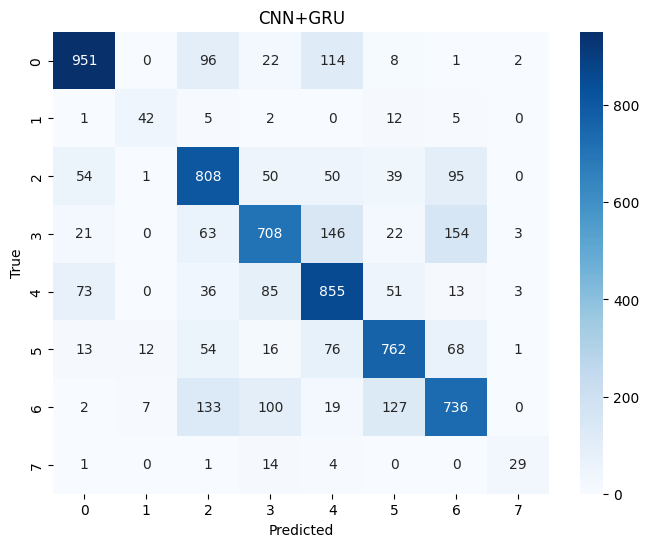

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.80      0.82      1194
           1       0.68      0.63      0.65        67
           2       0.68      0.74      0.70      1097
           3       0.71      0.63      0.67      1117
           4       0.68      0.77      0.72      1116
           5       0.75      0.76      0.75      1002
           6       0.69      0.65      0.67      1124
           7       0.76      0.59      0.67        49

    accuracy                           0.72      6766
   macro avg       0.72      0.70      0.71      6766
weighted avg       0.73      0.72      0.72      6766



In [58]:
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Get predictions
y_pred = model_cnn_gru.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1) # Convert to class labels
y_true = np.argmax(y_test, axis=1) # Convert one-hot encoded labels back to class labels

# Generate Confusion Matrix
conf_matrix = confusion_matrix(y_true, y_pred_classes)

# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap="Blues", xticklabels=range(8), yticklabels=range(8))
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('CNN+GRU')
plt.show()

# Print Classification Report
print("Classification Report:\n", classification_report(y_true, y_pred_classes))

212/212 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step


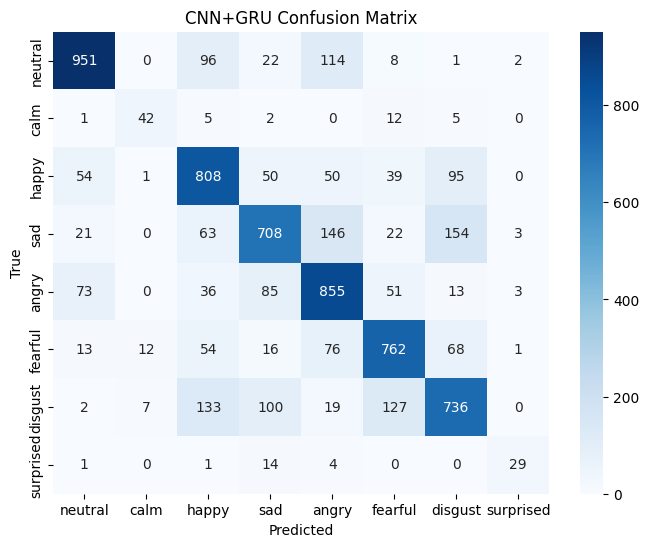

Classification Report:
               precision    recall  f1-score   support

     neutral       0.85      0.80      0.82      1194
        calm       0.68      0.63      0.65        67
       happy       0.68      0.74      0.70      1097
         sad       0.71      0.63      0.67      1117
       angry       0.68      0.77      0.72      1116
     fearful       0.75      0.76      0.75      1002
     disgust       0.69      0.65      0.67      1124
   surprised       0.76      0.59      0.67        49

    accuracy                           0.72      6766
   macro avg       0.72      0.70      0.71      6766
weighted avg       0.73      0.72      0.72      6766



In [59]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

# Define emotion labels
emotion_labels = ["neutral", "calm", "happy", "sad", "angry", "fearful", "disgust", "surprised"]

# Get predictions
y_pred = model_cnn_gru.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)  # Convert to class labels
y_true = np.argmax(y_test, axis=1)  # Convert one-hot encoded labels back to class labels

# Generate Confusion Matrix
conf_matrix = confusion_matrix(y_true, y_pred_classes)

# Plot Confusion Matrix with Emotion Labels
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap="Blues", xticklabels=emotion_labels, yticklabels=emotion_labels)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('CNN+GRU Confusion Matrix')
plt.show()

# Print Classification Report with Emotion Labels
print("Classification Report:\n", classification_report(y_true, y_pred_classes, target_names=emotion_labels))


In [60]:
import numpy as np
import pandas as pd

# Define emotion labels
emotion_labels = ["neutral", "calm", "happy", "sad", "angry", "fearful", "disgust", "surprised"]

# Get predictions
y_pred = model_cnn_gru.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)  # Convert to class labels
y_true = np.argmax(y_test, axis=1)  # Convert one-hot encoded labels back to class labels

# Create a DataFrame to display results
results_df = pd.DataFrame({
    "Actual Label": [emotion_labels[i] for i in y_true],
    "Predicted Label": [emotion_labels[i] for i in y_pred_classes]
})

# Display the first 10 results
print(results_df.head(10))


212/212 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step
  Actual Label Predicted Label
0      disgust         disgust
1      fearful         fearful
2          sad             sad
3      neutral         neutral
4        happy           happy
5      fearful         fearful
6        angry           angry
7      disgust           happy
8        happy         neutral
9      disgust         disgust


CNN

In [61]:
cnn_model=Sequential()
cnn_model.add(Conv1D(256, kernel_size=5, strides=1, padding='same', activation='relu', input_shape=(x_train.shape[1], 1)))
cnn_model.add(MaxPooling1D(pool_size=5, strides = 2, padding = 'same'))

cnn_model.add(Conv1D(256, kernel_size=5, strides=1, padding='same', activation='relu'))
cnn_model.add(MaxPooling1D(pool_size=5, strides = 2, padding = 'same'))

cnn_model.add(Conv1D(128, kernel_size=5, strides=1, padding='same', activation='relu'))
cnn_model.add(MaxPooling1D(pool_size=5, strides = 2, padding = 'same'))
cnn_model.add(Dropout(0.2))

cnn_model.add(Conv1D(64, kernel_size=5, strides=1, padding='same', activation='relu'))
cnn_model.add(MaxPooling1D(pool_size=5, strides = 2, padding = 'same'))

cnn_model.add(Flatten())
cnn_model.add(Dense(units=32, activation='relu'))
cnn_model.add(Dropout(0.3))

cnn_model.add(Dense(units=8, activation='softmax'))
cnn_model.compile(optimizer = 'adam' , loss = 'categorical_crossentropy' , metrics = ['accuracy'])

cnn_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d_7 (Conv1D)                    │ (None, 1620, 256)           │           1,536 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_7 (MaxPooling1D)       │ (None, 810, 256)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_8 (Conv1D)                    │ (None, 810, 256)            │         327,936 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_8 (MaxPooling1D)       │ (None, 405, 256)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_9 (Conv1D)                    │ (None, 405, 128)            │         163,968 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_9 (MaxPooling1D)       │ (None, 203, 128)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_12 (Dropout)                 │ (None, 203, 128)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_10 (Conv1D)                   │ (None, 203, 64)             │          41,024 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_10 (MaxPooling1D)      │ (None, 102, 64)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 6528)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 32)                  │         208,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_13 (Dropout)                 │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 8)                   │             264 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 743,656 (2.84 MB)

 Trainable params: 743,656 (2.84 MB)

 Non-trainable params: 0 (0.00 B)

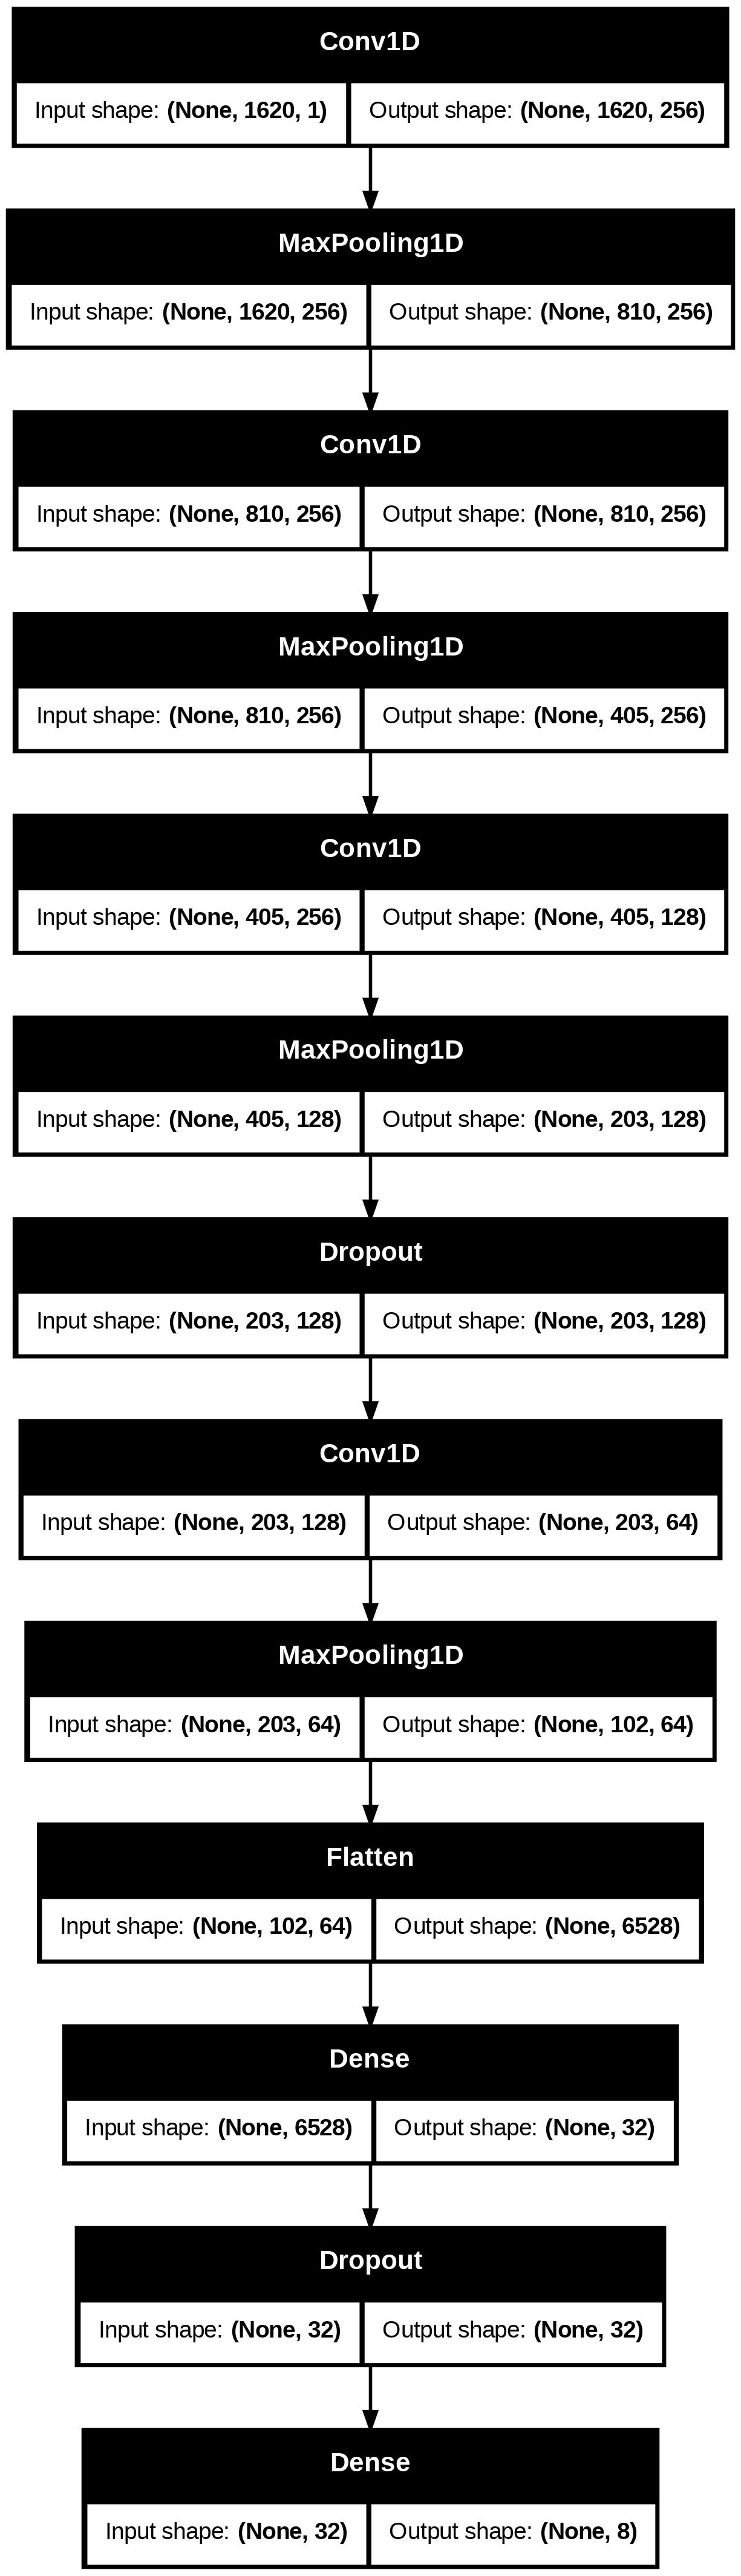

In [62]:
from keras.utils import plot_model  # Importing plot_model

plot_model(cnn_model, to_file='cnn_model_architecture.png', show_shapes=True)

In [63]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(monitor='val_accuracy', mode='max', patience=5, restore_best_weights=True)
lr_reduction = ReduceLROnPlateau(monitor='val_accuracy', patience=3, factor=0.5, min_lr=0.00001, verbose=1)
checkpoint = ModelCheckpoint('best_model.keras', monitor='val_accuracy', save_best_only=True, mode='max')


In [64]:


history_cnn= cnn_model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=50,  # Adjust based on performance
    batch_size=32,  # Try 32, 64, or 128 based on GPU memory
    callbacks=[early_stop, lr_reduction, checkpoint]
)


Epoch 1/50
846/846 ━━━━━━━━━━━━━━━━━━━━ 41s 42ms/step - accuracy: 0.2537 - loss: 1.8282 - val_accuracy: 0.3568 - val_loss: 1.6319 - learning_rate: 0.0010
Epoch 2/50
846/846 ━━━━━━━━━━━━━━━━━━━━ 26s 31ms/step - accuracy: 0.3575 - loss: 1.6015 - val_accuracy: 0.4030 - val_loss: 1.5071 - learning_rate: 0.0010
Epoch 3/50
846/846 ━━━━━━━━━━━━━━━━━━━━ 26s 31ms/step - accuracy: 0.3750 - loss: 1.5568 - val_accuracy: 0.4209 - val_loss: 1.4817 - learning_rate: 0.0010
Epoch 4/50
846/846 ━━━━━━━━━━━━━━━━━━━━ 26s 31ms/step - accuracy: 0.3884 - loss: 1.5258 - val_accuracy: 0.4220 - val_loss: 1.4617 - learning_rate: 0.0010
Epoch 5/50
846/846 ━━━━━━━━━━━━━━━━━━━━ 26s 31ms/step - accuracy: 0.3943 - loss: 1.5108 - val_accuracy: 0.4416 - val_loss: 1.4299 - learning_rate: 0.0010
Epoch 6/50
846/846 ━━━━━━━━━━━━━━━━━━━━ 26s 31ms/step - accuracy: 0.4062 - loss: 1.4852 - val_accuracy: 0.4338 - val_loss: 1.4299 - learning_rate: 0.0010
Epoch 7/50
846/846 ━━━━━━━━━━━━━━━━━━━━ 26s 31ms/step - accuracy: 0.4129 - l

Final Training Accuracy: 66.77%
Final Validation Accuracy: 66.52%
Final Training Loss: 0.7808
Final Validation Loss: 0.9294
212/212 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step
Test Accuracy: 66.57%
Precision: 67.59%
Recall: 66.57%
F1 Score: 66.36%


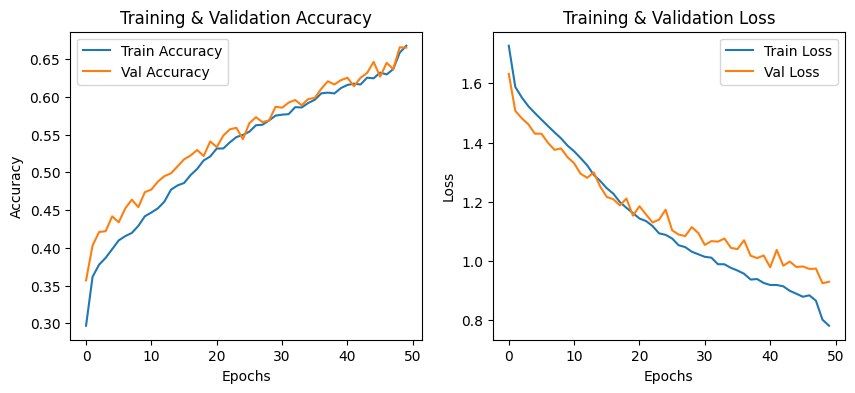

In [65]:

import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Extract metrics from history
train_loss = history_cnn.history['loss']
val_loss = history_cnn.history['val_loss']
train_acc = history_cnn.history['accuracy']
val_acc = history_cnn.history['val_accuracy']

# Print final values in percentages
print(f"Final Training Accuracy: {train_acc[-1] * 100:.2f}%")
print(f"Final Validation Accuracy: {val_acc[-1] * 100:.2f}%")
print(f"Final Training Loss: {train_loss[-1]:.4f}")
print(f"Final Validation Loss: {val_loss[-1]:.4f}")

# Get predictions
pred_test0 = cnn_model.predict(X_test)

# Convert softmax probabilities to class labels
y_pred0 = np.argmax(pred_test0, axis=1)
y_test0 = np.argmax(y_test, axis=1)

# Calculate evaluation metrics
accuracy = accuracy_score(y_test0, y_pred0) * 100
precision = precision_score(y_test0, y_pred0, average='weighted') * 100
recall = recall_score(y_test0, y_pred0, average='weighted') * 100
f1 = f1_score(y_test0, y_pred0, average='weighted') * 100

# Print values in percentage format
print(f"Test Accuracy: {accuracy:.2f}%")
print(f"Precision: {precision:.2f}%")
print(f"Recall: {recall:.2f}%")
print(f"F1 Score: {f1:.2f}%")

# Plot Training & Validation Accuracy
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(train_acc, label='Train Accuracy')
plt.plot(val_acc, label='Val Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training & Validation Accuracy')

# Plot Training & Validation Loss
plt.subplot(1, 2, 2)
plt.plot(train_loss, label='Train Loss')
plt.plot(val_loss, label='Val Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training & Validation Loss')

plt.show()

212/212 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


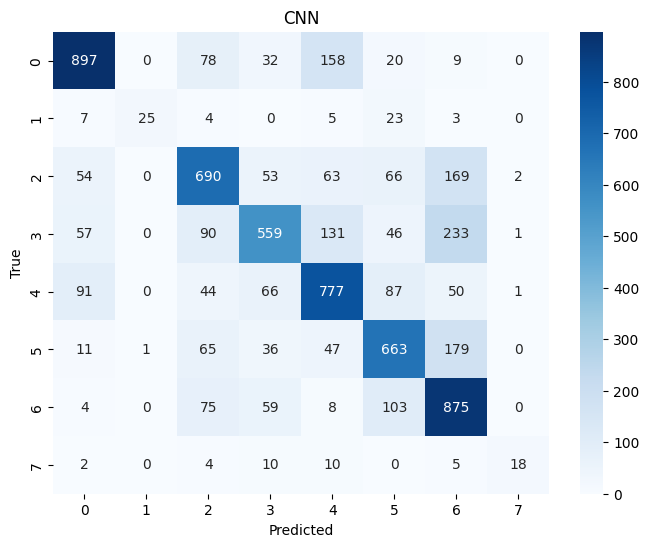

Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.75      0.77      1194
           1       0.96      0.37      0.54        67
           2       0.66      0.63      0.64      1097
           3       0.69      0.50      0.58      1117
           4       0.65      0.70      0.67      1116
           5       0.66      0.66      0.66      1002
           6       0.57      0.78      0.66      1124
           7       0.82      0.37      0.51        49

    accuracy                           0.67      6766
   macro avg       0.73      0.59      0.63      6766
weighted avg       0.68      0.67      0.66      6766



In [68]:
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Get predictions
y_pred = cnn_model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1) # Convert to class labels
y_true = np.argmax(y_test, axis=1) # Convert one-hot encoded labels back to class labels

# Generate Confusion Matrix
conf_matrix = confusion_matrix(y_true, y_pred_classes)

# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap="Blues", xticklabels=range(8), yticklabels=range(8))
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('CNN')
plt.show()

# Print Classification Report
print("Classification Report:\n", classification_report(y_true, y_pred_classes))

212/212 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step


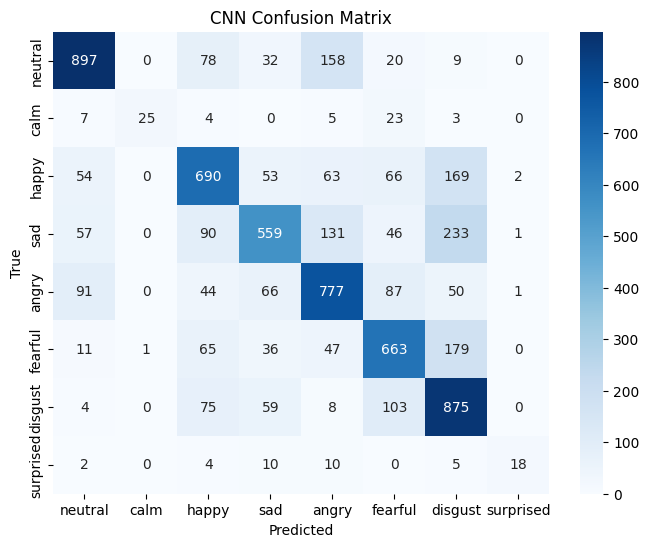

Classification Report:
               precision    recall  f1-score   support

     neutral       0.80      0.75      0.77      1194
        calm       0.96      0.37      0.54        67
       happy       0.66      0.63      0.64      1097
         sad       0.69      0.50      0.58      1117
       angry       0.65      0.70      0.67      1116
     fearful       0.66      0.66      0.66      1002
     disgust       0.57      0.78      0.66      1124
   surprised       0.82      0.37      0.51        49

    accuracy                           0.67      6766
   macro avg       0.73      0.59      0.63      6766
weighted avg       0.68      0.67      0.66      6766



In [69]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

# Define emotion labels
emotion_labels = ["neutral", "calm", "happy", "sad", "angry", "fearful", "disgust", "surprised"]

# Get predictions
y_pred = cnn_model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)  # Convert to class labels
y_true = np.argmax(y_test, axis=1)  # Convert one-hot encoded labels back to class labels

# Generate Confusion Matrix
conf_matrix = confusion_matrix(y_true, y_pred_classes)

# Plot Confusion Matrix with Emotion Labels
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap="Blues", xticklabels=emotion_labels, yticklabels=emotion_labels)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('CNN Confusion Matrix')
plt.show()

# Print Classification Report with Emotion Labels
print("Classification Report:\n", classification_report(y_true, y_pred_classes, target_names=emotion_labels))


In [70]:
import numpy as np
import pandas as pd

# Define emotion labels
emotion_labels = ["neutral", "calm", "happy", "sad", "angry", "fearful", "disgust", "surprised"]

# Get predictions
y_pred = cnn_model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)  # Convert to class labels
y_true = np.argmax(y_test, axis=1)  # Convert one-hot encoded labels back to class labels

# Create a DataFrame to display results
results_df = pd.DataFrame({
    "Actual Label": [emotion_labels[i] for i in y_true],
    "Predicted Label": [emotion_labels[i] for i in y_pred_classes]
})

# Display the first 10 results
print(results_df.head(10))


212/212 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
  Actual Label Predicted Label
0      disgust         disgust
1      fearful         disgust
2          sad           happy
3      neutral         neutral
4        happy           happy
5      fearful           happy
6        angry           angry
7      disgust           happy
8        happy             sad
9      disgust             sad


LSTM

In [78]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# Define LSTM Model
model_lstm = Sequential()

# First LSTM Layer
model_lstm.add(LSTM(128, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
model_lstm.add(Dropout(0.3))

# Second LSTM Layer
model_lstm.add(LSTM(128, return_sequences=True))
model_lstm.add(Dropout(0.3))

# Third LSTM Layer
model_lstm.add(LSTM(128))
model_lstm.add(Dropout(0.3))

# Fully Connected Layers
model_lstm.add(Dense(128, activation='relu'))
model_lstm.add(Dropout(0.3))
model_lstm.add(Dense(64, activation='relu'))
model_lstm.add(Dropout(0.3))
model_lstm.add(Dense(32, activation='relu'))

# Output Layer (8 classes for emotions)
model_lstm.add(Dense(8, activation='softmax'))

# Compile Model
model_lstm.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Model Summary
model_lstm.summary()


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_6 (LSTM)                        │ (None, 1620, 128)           │          66,560 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_19 (Dropout)                 │ (None, 1620, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_7 (LSTM)                        │ (None, 1620, 128)           │         131,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_20 (Dropout)                 │ (None, 1620, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_8 (LSTM)                        │ (None, 128)                 │         131,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_21 (Dropout)                 │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_14 (Dense)                     │ (None, 128)                 │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_22 (Dropout)                 │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_15 (Dense)                     │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_23 (Dropout)                 │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_16 (Dense)                     │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_17 (Dense)                     │ (None, 8)                   │             264 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 356,840 (1.36 MB)

 Trainable params: 356,840 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

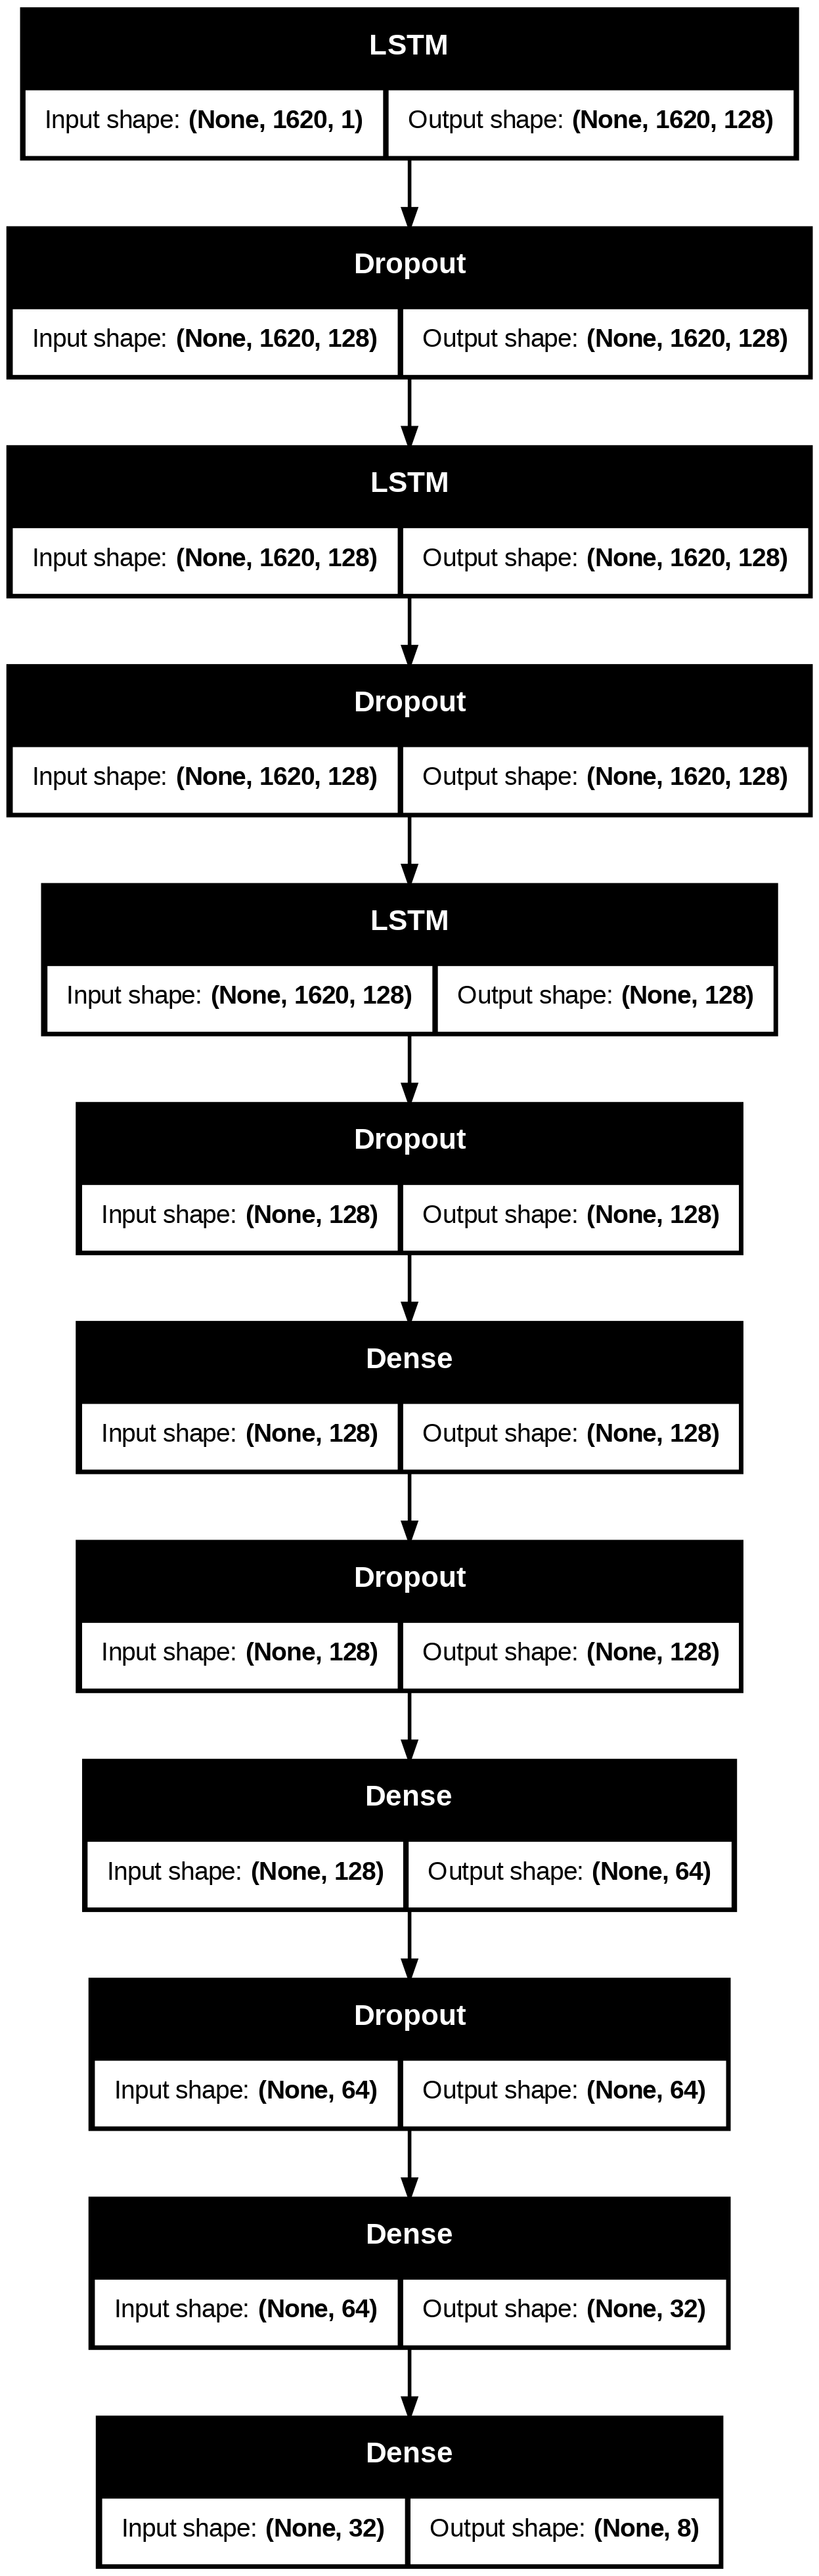

In [72]:
from keras.utils import plot_model  # Importing plot_model

plot_model(model_lstm, to_file='lstm_model_architecture.png', show_shapes=True)

In [79]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(monitor='val_accuracy', mode='max', patience=5, restore_best_weights=True)
lr_reduction = ReduceLROnPlateau(monitor='val_accuracy', patience=3, factor=0.5, min_lr=0.00001, verbose=1)
checkpoint = ModelCheckpoint('best_model.keras', monitor='val_accuracy', save_best_only=True, mode='max')


In [80]:
history_lstm= model_lstm.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=50,  # Adjust based on performance
    batch_size=128,  # Try 32, 64, or 128 based on GPU memory
    callbacks=[early_stop, lr_reduction, checkpoint]
)


Epoch 1/50
212/212 ━━━━━━━━━━━━━━━━━━━━ 71s 323ms/step - accuracy: 0.1653 - loss: 1.9422 - val_accuracy: 0.1821 - val_loss: 1.8390 - learning_rate: 0.0010
Epoch 2/50
212/212 ━━━━━━━━━━━━━━━━━━━━ 68s 322ms/step - accuracy: 0.1945 - loss: 1.8442 - val_accuracy: 0.2006 - val_loss: 1.8322 - learning_rate: 0.0010
Epoch 3/50
212/212 ━━━━━━━━━━━━━━━━━━━━ 68s 322ms/step - accuracy: 0.1902 - loss: 1.8449 - val_accuracy: 0.2010 - val_loss: 1.8345 - learning_rate: 0.0010
Epoch 4/50
212/212 ━━━━━━━━━━━━━━━━━━━━ 70s 329ms/step - accuracy: 0.1740 - loss: 1.8612 - val_accuracy: 0.1649 - val_loss: 1.8613 - learning_rate: 0.0010
Epoch 5/50
212/212 ━━━━━━━━━━━━━━━━━━━━ 70s 331ms/step - accuracy: 0.1700 - loss: 1.8639 - val_accuracy: 0.1765 - val_loss: 1.8586 - learning_rate: 0.0010
Epoch 6/50
212/212 ━━━━━━━━━━━━━━━━━━━━ 0s 302ms/step - accuracy: 0.1696 - loss: 1.8602
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
212/212 ━━━━━━━━━━━━━━━━━━━━ 70s 331ms/step - accuracy: 0.169

Final Training Accuracy: 16.69%
Final Validation Accuracy: 17.65%
Final Training Loss: 1.8607
Final Validation Loss: 1.8585
212/212 ━━━━━━━━━━━━━━━━━━━━ 13s 58ms/step
Test Accuracy: 20.10%
Precision: 18.32%
Recall: 20.10%
F1 Score: 11.25%


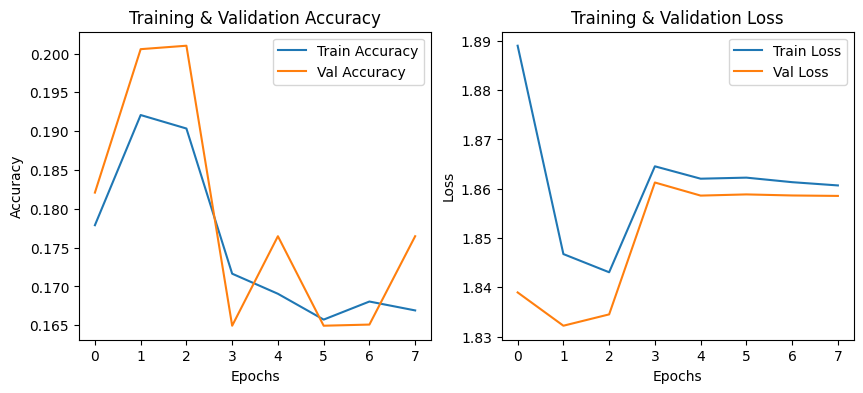

In [90]:

import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Extract metrics from history
train_loss = history_lstm.history['loss']
val_loss = history_lstm.history['val_loss']
train_acc = history_lstm.history['accuracy']
val_acc = history_lstm.history['val_accuracy']

# Print final values in percentages
print(f"Final Training Accuracy: {train_acc[-1] * 100:.2f}%")
print(f"Final Validation Accuracy: {val_acc[-1] * 100:.2f}%")
print(f"Final Training Loss: {train_loss[-1]:.4f}")
print(f"Final Validation Loss: {val_loss[-1]:.4f}")

# Get predictions
pred_test0 = model_lstm.predict(X_test)

# Convert softmax probabilities to class labels
y_pred0 = np.argmax(pred_test0, axis=1)
y_test0 = np.argmax(y_test, axis=1)

# Calculate evaluation metrics
accuracy = accuracy_score(y_test0, y_pred0) * 100
precision = precision_score(y_test0, y_pred0, average='weighted') * 100
recall = recall_score(y_test0, y_pred0, average='weighted') * 100
f1 = f1_score(y_test0, y_pred0, average='weighted') * 100

# Print values in percentage format
print(f"Test Accuracy: {accuracy:.2f}%")
print(f"Precision: {precision:.2f}%")
print(f"Recall: {recall:.2f}%")
print(f"F1 Score: {f1:.2f}%")

# Plot Training & Validation Accuracy
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(train_acc, label='Train Accuracy')
plt.plot(val_acc, label='Val Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training & Validation Accuracy')

# Plot Training & Validation Loss
plt.subplot(1, 2, 2)
plt.plot(train_loss, label='Train Loss')
plt.plot(val_loss, label='Val Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training & Validation Loss')

plt.show()

212/212 ━━━━━━━━━━━━━━━━━━━━ 12s 57ms/step


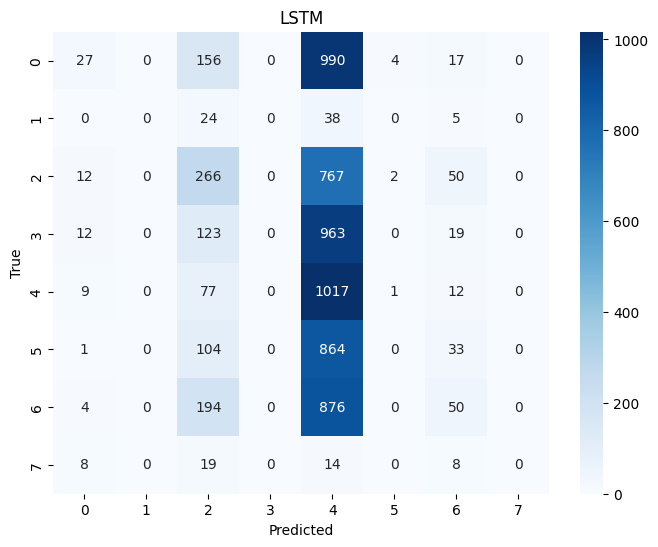

Classification Report:
               precision    recall  f1-score   support

           0       0.37      0.02      0.04      1194
           1       0.00      0.00      0.00        67
           2       0.28      0.24      0.26      1097
           3       0.00      0.00      0.00      1117
           4       0.18      0.91      0.31      1116
           5       0.00      0.00      0.00      1002
           6       0.26      0.04      0.08      1124
           7       0.00      0.00      0.00        49

    accuracy                           0.20      6766
   macro avg       0.14      0.15      0.09      6766
weighted avg       0.18      0.20      0.11      6766



In [91]:
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Get predictions
y_pred = model_lstm.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1) # Convert to class labels
y_true = np.argmax(y_test, axis=1) # Convert one-hot encoded labels back to class labels

# Generate Confusion Matrix
conf_matrix = confusion_matrix(y_true, y_pred_classes)

# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap="Blues", xticklabels=range(8), yticklabels=range(8))
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('LSTM')
plt.show()

# Print Classification Report
print("Classification Report:\n", classification_report(y_true, y_pred_classes))

212/212 ━━━━━━━━━━━━━━━━━━━━ 12s 57ms/step


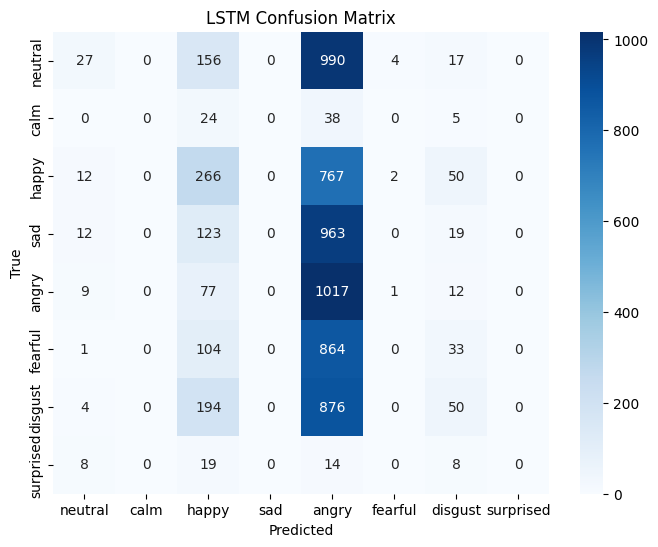

Classification Report:
               precision    recall  f1-score   support

     neutral       0.37      0.02      0.04      1194
        calm       0.00      0.00      0.00        67
       happy       0.28      0.24      0.26      1097
         sad       0.00      0.00      0.00      1117
       angry       0.18      0.91      0.31      1116
     fearful       0.00      0.00      0.00      1002
     disgust       0.26      0.04      0.08      1124
   surprised       0.00      0.00      0.00        49

    accuracy                           0.20      6766
   macro avg       0.14      0.15      0.09      6766
weighted avg       0.18      0.20      0.11      6766



In [92]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

# Define emotion labels
emotion_labels = ["neutral", "calm", "happy", "sad", "angry", "fearful", "disgust", "surprised"]

# Get predictions
y_pred = model_lstm.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)  # Convert to class labels
y_true = np.argmax(y_test, axis=1)  # Convert one-hot encoded labels back to class labels

# Generate Confusion Matrix
conf_matrix = confusion_matrix(y_true, y_pred_classes)

# Plot Confusion Matrix with Emotion Labels
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap="Blues", xticklabels=emotion_labels, yticklabels=emotion_labels)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('LSTM Confusion Matrix')
plt.show()

# Print Classification Report with Emotion Labels
print("Classification Report:\n", classification_report(y_true, y_pred_classes, target_names=emotion_labels))


In [93]:
import numpy as np
import pandas as pd

# Define emotion labels
emotion_labels = ["neutral", "calm", "happy", "sad", "angry", "fearful", "disgust", "surprised"]

# Get predictions
y_pred = model_lstm.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)  # Convert to class labels
y_true = np.argmax(y_test, axis=1)  # Convert one-hot encoded labels back to class labels

# Create a DataFrame to display results
results_df = pd.DataFrame({
    "Actual Label": [emotion_labels[i] for i in y_true],
    "Predicted Label": [emotion_labels[i] for i in y_pred_classes]
})

# Display the first 10 results
print(results_df.head(10))


212/212 ━━━━━━━━━━━━━━━━━━━━ 12s 56ms/step
  Actual Label Predicted Label
0      disgust           happy
1      fearful         disgust
2          sad           happy
3      neutral           angry
4        happy         disgust
5      fearful           angry
6        angry           angry
7      disgust           happy
8        happy           angry
9      disgust           angry


GRU

In [81]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout

# Define GRU Model
model_gru = Sequential()

# First GRU Layer
model_gru.add(GRU(128, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
model_gru.add(Dropout(0.3))

# Second GRU Layer
model_gru.add(GRU(128, return_sequences=True))
model_gru.add(Dropout(0.3))

# Third GRU Layer
model_gru.add(GRU(128))
model_gru.add(Dropout(0.3))

# Fully Connected Layers
model_gru.add(Dense(128, activation='relu'))
model_gru.add(Dropout(0.3))
model_gru.add(Dense(64, activation='relu'))
model_gru.add(Dropout(0.3))
model_gru.add(Dense(32, activation='relu'))

# Output Layer (8 classes for emotions)
model_gru.add(Dense(8, activation='softmax'))

# Compile Model
model_gru.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Model Summary
model_gru.summary()


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ gru_4 (GRU)                          │ (None, 1620, 128)           │          50,304 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_24 (Dropout)                 │ (None, 1620, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ gru_5 (GRU)                          │ (None, 1620, 128)           │          99,072 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_25 (Dropout)                 │ (None, 1620, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ gru_6 (GRU)                          │ (None, 128)                 │          99,072 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_26 (Dropout)                 │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_18 (Dense)                     │ (None, 128)                 │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_27 (Dropout)                 │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_19 (Dense)                     │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_28 (Dropout)                 │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_20 (Dense)                     │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_21 (Dense)                     │ (None, 8)                   │             264 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 275,560 (1.05 MB)

 Trainable params: 275,560 (1.05 MB)

 Non-trainable params: 0 (0.00 B)

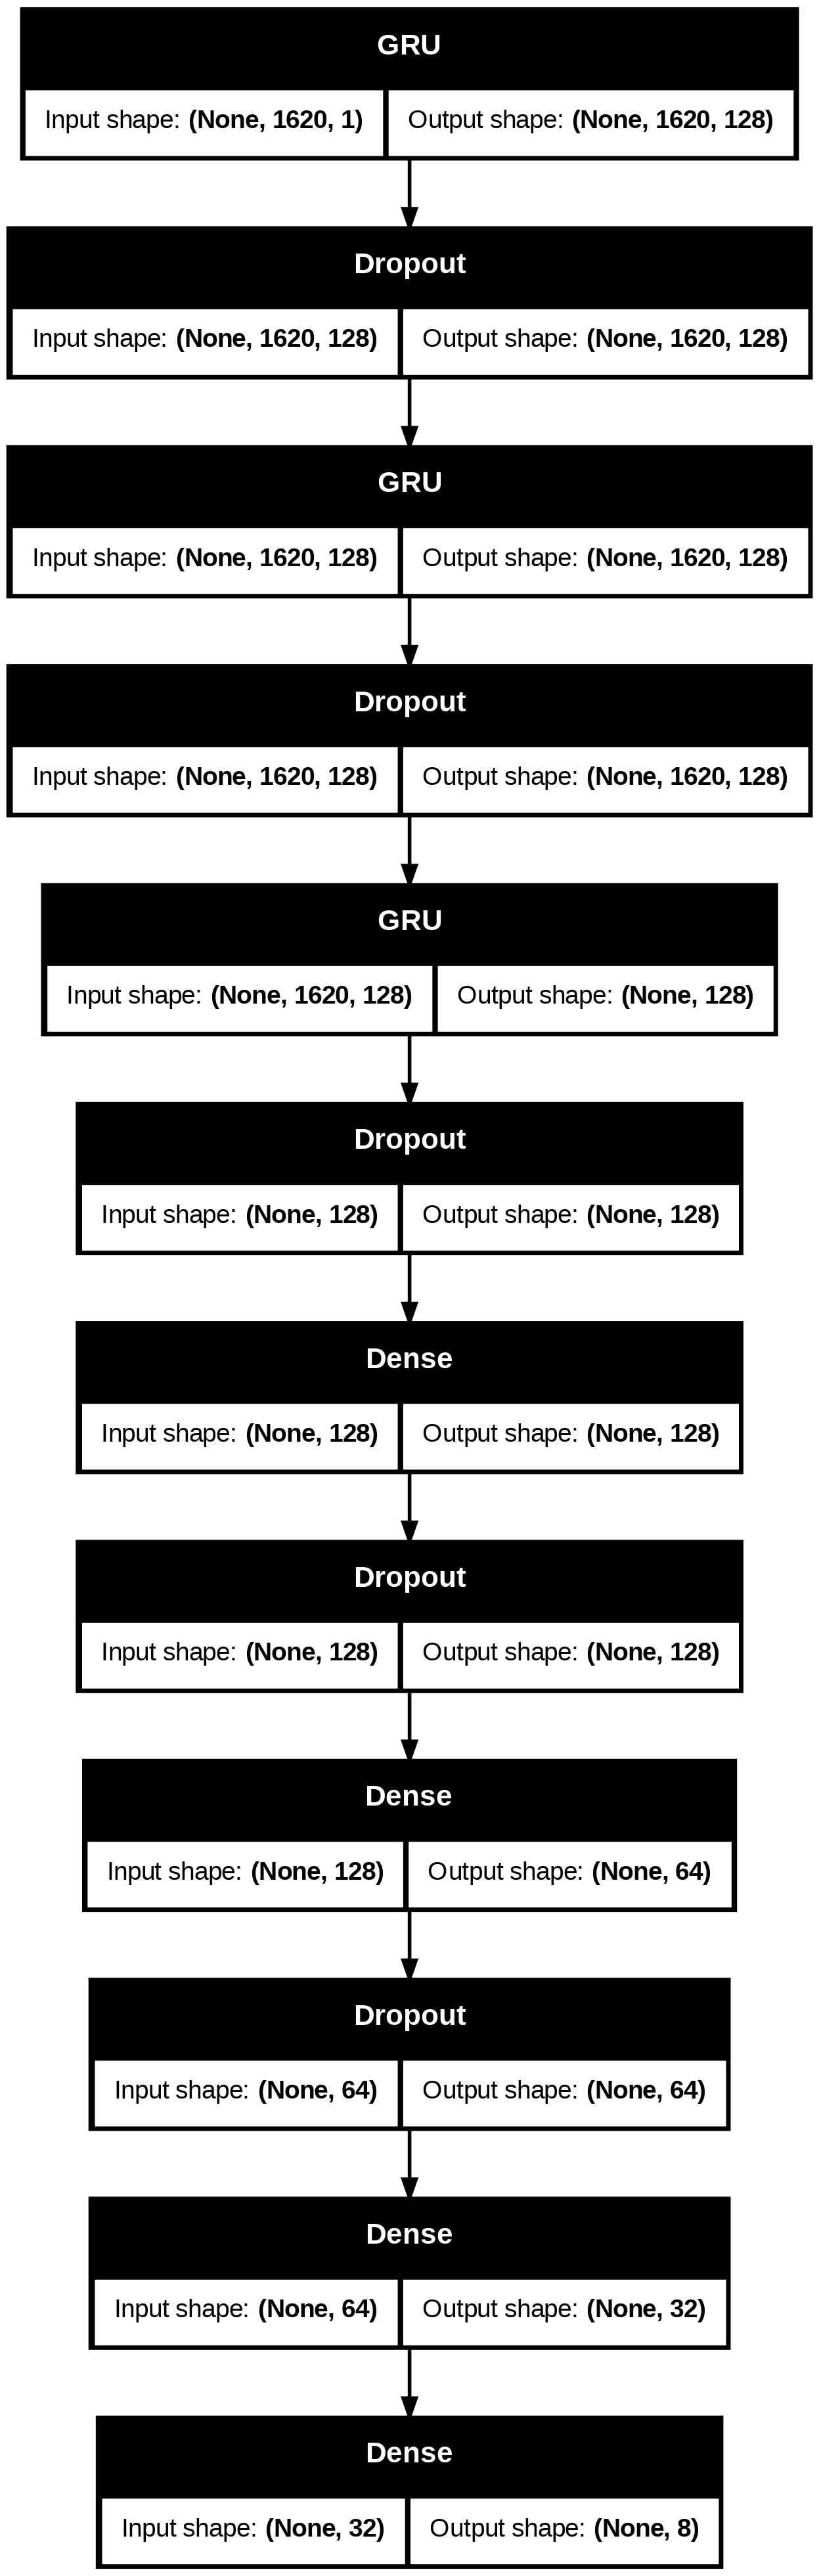

In [82]:
from keras.utils import plot_model  # Importing plot_model

plot_model(model_gru, to_file='gru_model_architecture.png', show_shapes=True)

In [83]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(monitor='val_accuracy', mode='max', patience=5, restore_best_weights=True)
lr_reduction = ReduceLROnPlateau(monitor='val_accuracy', patience=3, factor=0.5, min_lr=0.00001, verbose=1)
checkpoint = ModelCheckpoint('best_model.keras', monitor='val_accuracy', save_best_only=True, mode='max')


In [85]:
history_gru= model_gru.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=50,  # Adjust based on performance
    batch_size=128,  # Try 32, 64, or 128 based on GPU memory
    callbacks=[early_stop, lr_reduction, checkpoint]
)


Epoch 1/50
212/212 ━━━━━━━━━━━━━━━━━━━━ 61s 288ms/step - accuracy: 0.1784 - loss: 1.8580 - val_accuracy: 0.1972 - val_loss: 1.8312 - learning_rate: 0.0010
Epoch 2/50
212/212 ━━━━━━━━━━━━━━━━━━━━ 60s 284ms/step - accuracy: 0.1925 - loss: 1.8472 - val_accuracy: 0.1994 - val_loss: 1.8266 - learning_rate: 0.0010
Epoch 3/50
212/212 ━━━━━━━━━━━━━━━━━━━━ 60s 284ms/step - accuracy: 0.1949 - loss: 1.8387 - val_accuracy: 0.1994 - val_loss: 1.8274 - learning_rate: 0.0010
Epoch 4/50
212/212 ━━━━━━━━━━━━━━━━━━━━ 61s 286ms/step - accuracy: 0.1895 - loss: 1.8382 - val_accuracy: 0.1969 - val_loss: 1.8357 - learning_rate: 0.0010
Epoch 5/50
212/212 ━━━━━━━━━━━━━━━━━━━━ 61s 286ms/step - accuracy: 0.1976 - loss: 1.8389 - val_accuracy: 0.2031 - val_loss: 1.8191 - learning_rate: 0.0010
Epoch 6/50
212/212 ━━━━━━━━━━━━━━━━━━━━ 61s 288ms/step - accuracy: 0.1975 - loss: 1.8354 - val_accuracy: 0.1966 - val_loss: 1.8222 - learning_rate: 0.0010
Epoch 7/50
212/212 ━━━━━━━━━━━━━━━━━━━━ 61s 288ms/step - accuracy: 0.2

Final Training Accuracy: 20.09%
Final Validation Accuracy: 20.19%
Final Training Loss: 1.8196
Final Validation Loss: 1.8147
212/212 ━━━━━━━━━━━━━━━━━━━━ 11s 52ms/step
Test Accuracy: 20.31%
Precision: 18.07%
Recall: 20.31%
F1 Score: 11.64%


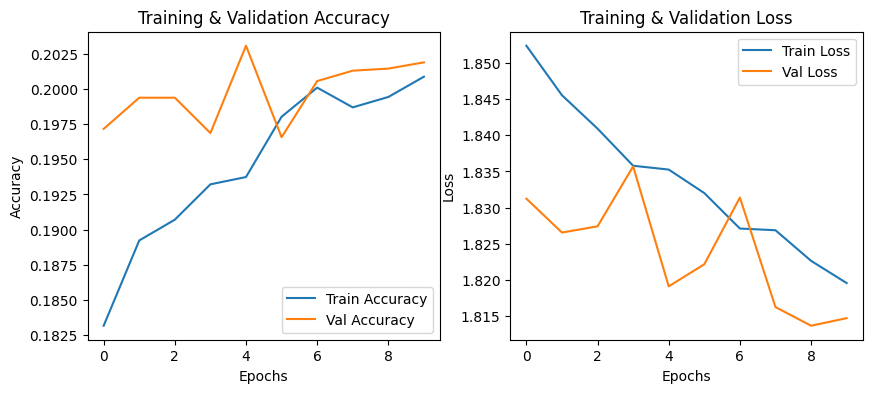

In [86]:

import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Extract metrics from history
train_loss = history_gru.history['loss']
val_loss = history_gru.history['val_loss']
train_acc = history_gru.history['accuracy']
val_acc = history_gru.history['val_accuracy']

# Print final values in percentages
print(f"Final Training Accuracy: {train_acc[-1] * 100:.2f}%")
print(f"Final Validation Accuracy: {val_acc[-1] * 100:.2f}%")
print(f"Final Training Loss: {train_loss[-1]:.4f}")
print(f"Final Validation Loss: {val_loss[-1]:.4f}")

# Get predictions
pred_test0 = model_gru.predict(X_test)

# Convert softmax probabilities to class labels
y_pred0 = np.argmax(pred_test0, axis=1)
y_test0 = np.argmax(y_test, axis=1)

# Calculate evaluation metrics
accuracy = accuracy_score(y_test0, y_pred0) * 100
precision = precision_score(y_test0, y_pred0, average='weighted') * 100
recall = recall_score(y_test0, y_pred0, average='weighted') * 100
f1 = f1_score(y_test0, y_pred0, average='weighted') * 100

# Print values in percentage format
print(f"Test Accuracy: {accuracy:.2f}%")
print(f"Precision: {precision:.2f}%")
print(f"Recall: {recall:.2f}%")
print(f"F1 Score: {f1:.2f}%")

# Plot Training & Validation Accuracy
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(train_acc, label='Train Accuracy')
plt.plot(val_acc, label='Val Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training & Validation Accuracy')

# Plot Training & Validation Loss
plt.subplot(1, 2, 2)
plt.plot(train_loss, label='Train Loss')
plt.plot(val_loss, label='Val Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training & Validation Loss')

plt.show()

212/212 ━━━━━━━━━━━━━━━━━━━━ 11s 52ms/step


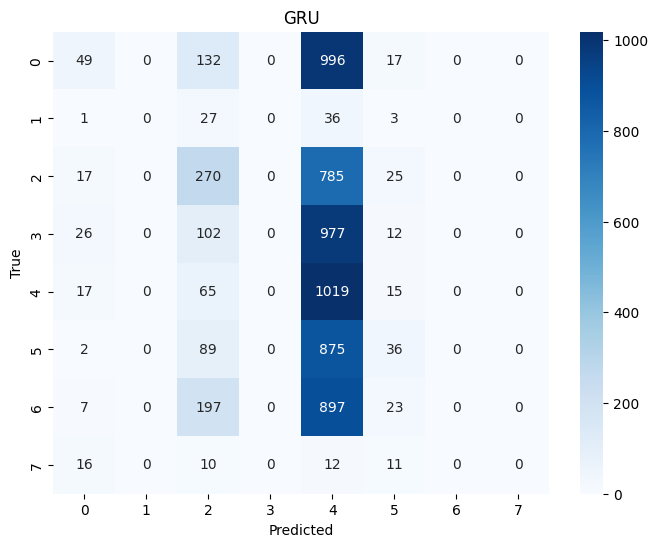

Classification Report:
               precision    recall  f1-score   support

           0       0.36      0.04      0.07      1194
           1       0.00      0.00      0.00        67
           2       0.30      0.25      0.27      1097
           3       0.00      0.00      0.00      1117
           4       0.18      0.91      0.30      1116
           5       0.25      0.04      0.06      1002
           6       0.00      0.00      0.00      1124
           7       0.00      0.00      0.00        49

    accuracy                           0.20      6766
   macro avg       0.14      0.15      0.09      6766
weighted avg       0.18      0.20      0.12      6766



In [87]:
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Get predictions
y_pred = model_gru.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1) # Convert to class labels
y_true = np.argmax(y_test, axis=1) # Convert one-hot encoded labels back to class labels

# Generate Confusion Matrix
conf_matrix = confusion_matrix(y_true, y_pred_classes)

# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap="Blues", xticklabels=range(8), yticklabels=range(8))
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('GRU')
plt.show()

# Print Classification Report
print("Classification Report:\n", classification_report(y_true, y_pred_classes))

212/212 ━━━━━━━━━━━━━━━━━━━━ 11s 52ms/step


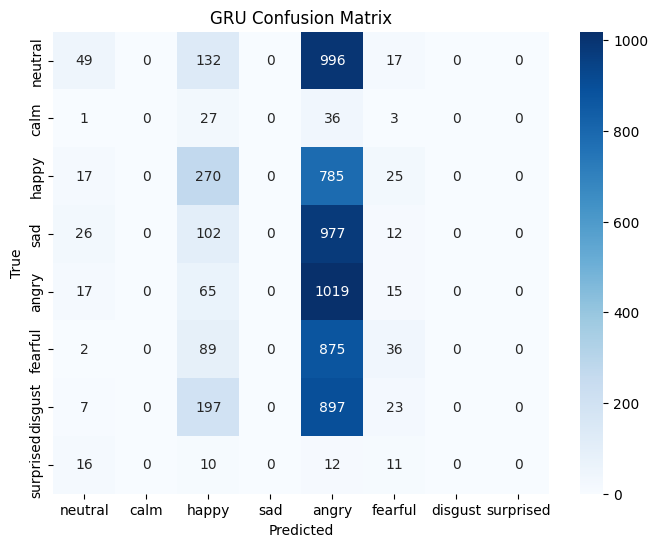

Classification Report:
               precision    recall  f1-score   support

     neutral       0.36      0.04      0.07      1194
        calm       0.00      0.00      0.00        67
       happy       0.30      0.25      0.27      1097
         sad       0.00      0.00      0.00      1117
       angry       0.18      0.91      0.30      1116
     fearful       0.25      0.04      0.06      1002
     disgust       0.00      0.00      0.00      1124
   surprised       0.00      0.00      0.00        49

    accuracy                           0.20      6766
   macro avg       0.14      0.15      0.09      6766
weighted avg       0.18      0.20      0.12      6766



In [88]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

# Define emotion labels
emotion_labels = ["neutral", "calm", "happy", "sad", "angry", "fearful", "disgust", "surprised"]

# Get predictions
y_pred = model_gru.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)  # Convert to class labels
y_true = np.argmax(y_test, axis=1)  # Convert one-hot encoded labels back to class labels

# Generate Confusion Matrix
conf_matrix = confusion_matrix(y_true, y_pred_classes)

# Plot Confusion Matrix with Emotion Labels
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap="Blues", xticklabels=emotion_labels, yticklabels=emotion_labels)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('GRU Confusion Matrix')
plt.show()

# Print Classification Report with Emotion Labels
print("Classification Report:\n", classification_report(y_true, y_pred_classes, target_names=emotion_labels))


In [89]:
import numpy as np
import pandas as pd

# Define emotion labels
emotion_labels = ["neutral", "calm", "happy", "sad", "angry", "fearful", "disgust", "surprised"]

# Get predictions
y_pred = model_gru.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)  # Convert to class labels
y_true = np.argmax(y_test, axis=1)  # Convert one-hot encoded labels back to class labels

# Create a DataFrame to display results
results_df = pd.DataFrame({
    "Actual Label": [emotion_labels[i] for i in y_true],
    "Predicted Label": [emotion_labels[i] for i in y_pred_classes]
})

# Display the first 10 results
print(results_df.head(10))


212/212 ━━━━━━━━━━━━━━━━━━━━ 11s 51ms/step
  Actual Label Predicted Label
0      disgust           happy
1      fearful           happy
2          sad           happy
3      neutral           angry
4        happy           happy
5      fearful           angry
6        angry           angry
7      disgust           happy
8        happy           angry
9      disgust           angry


cnn-attention-bilstm

In [99]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, Conv1D, MaxPooling1D, Flatten, Dense, Dropout, 
                                     BatchNormalization, Bidirectional, LSTM, Multiply, 
                                     Permute, Lambda, Softmax)
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam

# Function to create an Improved Attention Layer
def attention_block(inputs):
    """Improved Attention Mechanism using Dot Product Attention"""
    attention = Dense(inputs.shape[-1], activation='tanh')(inputs)  # Compute attention scores
    attention = Softmax()(attention)  # Apply softmax normalization
    attention = Multiply()([inputs, attention])  # Apply attention to inputs
    return attention

# Define Improved CNN + Attention + BiLSTM model
def create_improved_cnn_attention_bilstm(input_shape, num_classes):
    inputs = Input(shape=input_shape)

    # CNN Feature Extraction (Deeper)
    x = Conv1D(filters=128, kernel_size=5, activation='relu', padding='same', kernel_regularizer=l2(0.01))(inputs)
    x = BatchNormalization()(x)
    x = MaxPooling1D(pool_size=2)(x)
    x = Dropout(0.3)(x)

    x = Conv1D(filters=256, kernel_size=5, activation='relu', padding='same', kernel_regularizer=l2(0.01))(x)
    x = BatchNormalization()(x)
    x = MaxPooling1D(pool_size=2)(x)
    x = Dropout(0.3)(x)

    x = Conv1D(filters=512, kernel_size=3, activation='relu', padding='same', kernel_regularizer=l2(0.01))(x)
    x = BatchNormalization()(x)
    x = MaxPooling1D(pool_size=2)(x)
    x = Dropout(0.3)(x)

    # Attention Mechanism
    x = attention_block(x)

    # BiLSTM Layer (Increased LSTM Units)
    x = Bidirectional(LSTM(256, return_sequences=True, dropout=0.3))(x)
    x = Bidirectional(LSTM(128, return_sequences=True, dropout=0.3))(x)
    x = Bidirectional(LSTM(64, dropout=0.3))(x)

    # Fully Connected Layers
    x = Dense(128, activation='relu', kernel_regularizer=l2(0.01))(x)
    x = Dropout(0.3)(x)
    x = Dense(64, activation='relu', kernel_regularizer=l2(0.01))(x)
    x = Dropout(0.3)(x)

    # Output Layer (8 classes for emotions)
    outputs = Dense(num_classes, activation='softmax')(x)

    # Compile Model with Learning Rate Scheduling
    optimizer = Adam(learning_rate=0.0005)  # Adjusted Learning Rate
    model = Model(inputs, outputs)
    model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

    return model

# Example usage
input_shape = (1620, 1)  # Adjust based on feature extraction
num_classes = 8  # Number of emotion categories

model_cab = create_improved_cnn_attention_bilstm(input_shape, num_classes)
model_cab.summary()


Model: "functional_74"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_8             │ (None, 1620, 1)        │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1d_14 (Conv1D)        │ (None, 1620, 128)      │            768 │ input_layer_8[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_10    │ (None, 1620, 128)      │            512 │ conv1d_14[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling1d_14          │ (None, 810, 128)       │              0 │ batch_normalization_1… │
│ (MaxPooling1D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_34 (Dropout)      │ (None, 810, 128)       │              0 │ max_pooling1d_14[0][0] │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1d_15 (Conv1D)        │ (None, 810, 256)       │        164,096 │ dropout_34[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_11    │ (None, 810, 256)       │          1,024 │ conv1d_15[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling1d_15          │ (None, 405, 256)       │              0 │ batch_normalization_1… │
│ (MaxPooling1D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_35 (Dropout)      │ (None, 405, 256)       │              0 │ max_pooling1d_15[0][0] │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1d_16 (Conv1D)        │ (None, 405, 512)       │        393,728 │ dropout_35[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_12    │ (None, 405, 512)       │          2,048 │ conv1d_16[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling1d_16          │ (None, 202, 512)       │              0 │ batch_normalization_1… │
│ (MaxPooling1D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_36 (Dropout)      │ (None, 202, 512)       │              0 │ max_pooling1d_16[0][0] │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_26 (Dense)          │ (None, 202, 512)       │        262,656 │ dropout_36[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ softmax_1 (Softmax)       │ (None, 202, 512)       │              0 │ dense_26[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ multiply_1 (Multiply)     │ (None, 202, 512)       │              0 │ dropout_36[0][0],      │
│                      

 Total params: 3,245,768 (12.38 MB)

 Trainable params: 3,243,976 (12.37 MB)

 Non-trainable params: 1,792 (7.00 KB)

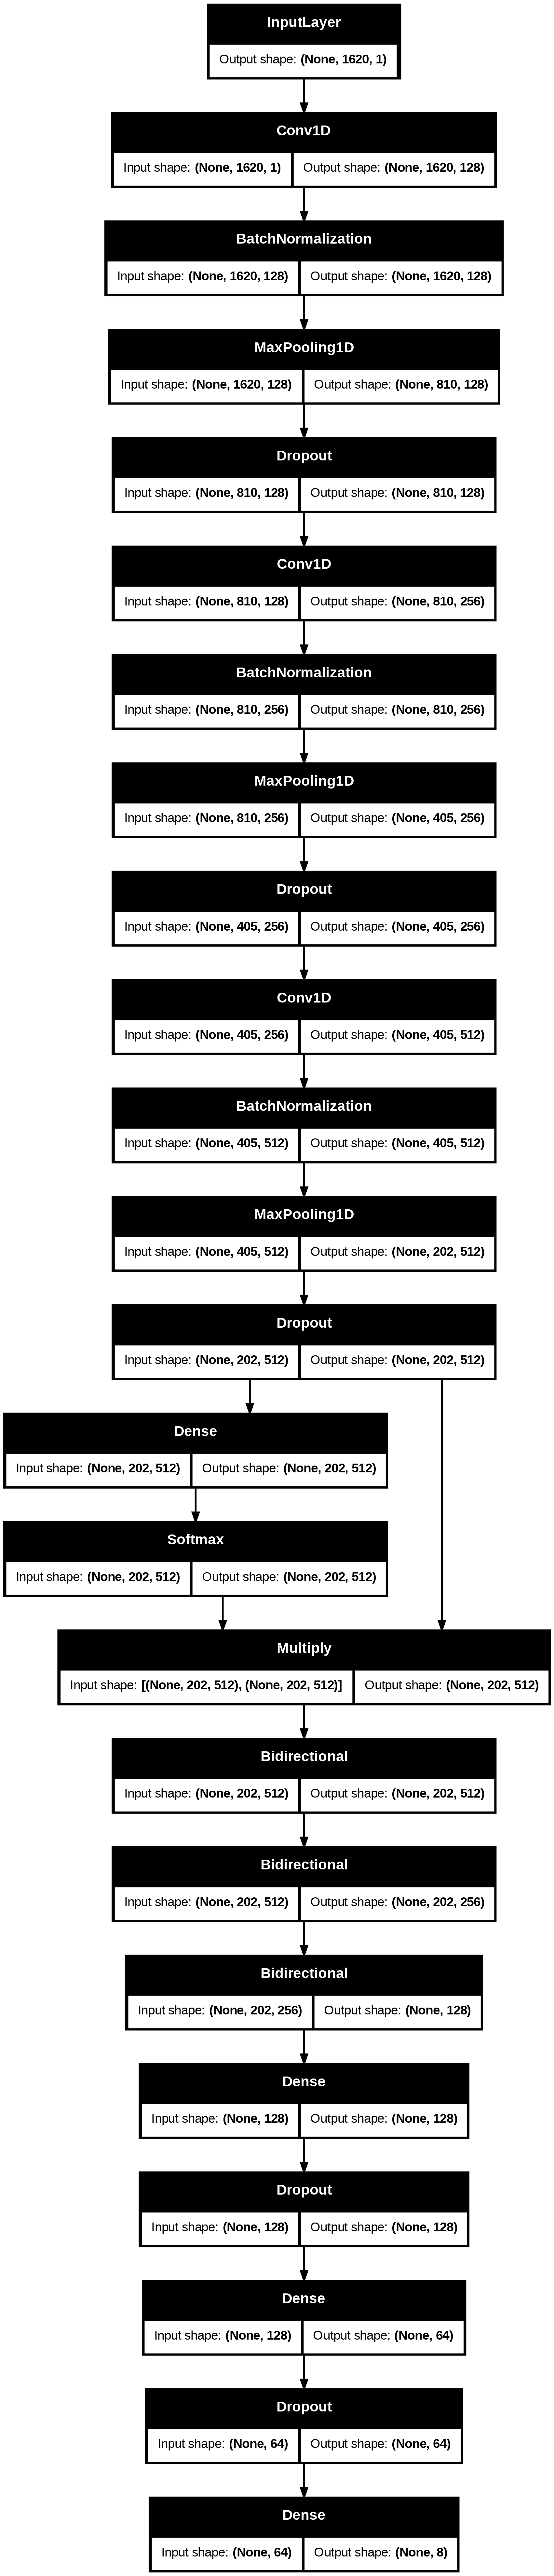

In [95]:
from keras.utils import plot_model  # Importing plot_model

plot_model(model_cab, to_file='cab_model_architecture.png', show_shapes=True)

In [ ]:
history_cab = model_cab.fit(x_train, y_train, validation_data=(x_test, y_test), epochs=30, batch_size=64)


In [ ]:

import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Extract metrics from history
train_loss = history_cab.history['loss']
val_loss = history_cab.history['val_loss']
train_acc = history_cab.history['accuracy']
val_acc = history_cab.history['val_accuracy']

# Print final values in percentages
print(f"Final Training Accuracy: {train_acc[-1] * 100:.2f}%")
print(f"Final Validation Accuracy: {val_acc[-1] * 100:.2f}%")
print(f"Final Training Loss: {train_loss[-1]:.4f}")
print(f"Final Validation Loss: {val_loss[-1]:.4f}")

# Get predictions
pred_test0 = model_cab.predict(X_test)

# Convert softmax probabilities to class labels
y_pred0 = np.argmax(pred_test0, axis=1)
y_test0 = np.argmax(y_test, axis=1)

# Calculate evaluation metrics
accuracy = accuracy_score(y_test0, y_pred0) * 100
precision = precision_score(y_test0, y_pred0, average='weighted') * 100
recall = recall_score(y_test0, y_pred0, average='weighted') * 100
f1 = f1_score(y_test0, y_pred0, average='weighted') * 100

# Print values in percentage format
print(f"Test Accuracy: {accuracy:.2f}%")
print(f"Precision: {precision:.2f}%")
print(f"Recall: {recall:.2f}%")
print(f"F1 Score: {f1:.2f}%")

# Plot Training & Validation Accuracy
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(train_acc, label='Train Accuracy')
plt.plot(val_acc, label='Val Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training & Validation Accuracy')

# Plot Training & Validation Loss
plt.subplot(1, 2, 2)
plt.plot(train_loss, label='Train Loss')
plt.plot(val_loss, label='Val Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training & Validation Loss')

plt.show()

In [ ]:
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Get predictions
y_pred = model_cab.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1) # Convert to class labels
y_true = np.argmax(y_test, axis=1) # Convert one-hot encoded labels back to class labels

# Generate Confusion Matrix
conf_matrix = confusion_matrix(y_true, y_pred_classes)

# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap="Blues", xticklabels=range(8), yticklabels=range(8))
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('CNN+Attention+BiLSTM')
plt.show()

# Print Classification Report
print("Classification Report:\n", classification_report(y_true, y_pred_classes))

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

# Define emotion labels
emotion_labels = ["neutral", "calm", "happy", "sad", "angry", "fearful", "disgust", "surprised"]

# Get predictions
y_pred = model_cab.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)  # Convert to class labels
y_true = np.argmax(y_test, axis=1)  # Convert one-hot encoded labels back to class labels

# Generate Confusion Matrix
conf_matrix = confusion_matrix(y_true, y_pred_classes)

# Plot Confusion Matrix with Emotion Labels
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap="Blues", xticklabels=emotion_labels, yticklabels=emotion_labels)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('CNN+Attention+BiLSTM Confusion Matrix')
plt.show()

# Print Classification Report with Emotion Labels
print("Classification Report:\n", classification_report(y_true, y_pred_classes, target_names=emotion_labels))


In [ ]:
import numpy as np
import pandas as pd

# Define emotion labels
emotion_labels = ["neutral", "calm", "happy", "sad", "angry", "fearful", "disgust", "surprised"]

# Get predictions
y_pred = model_cab.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)  # Convert to class labels
y_true = np.argmax(y_test, axis=1)  # Convert one-hot encoded labels back to class labels

# Create a DataFrame to display results
results_df = pd.DataFrame({
    "Actual Label": [emotion_labels[i] for i in y_true],
    "Predicted Label": [emotion_labels[i] for i in y_pred_classes]
})

# Display the first 10 results
print(results_df.head(10))
